In [19]:
from collections import Counter, defaultdict
import time
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.metrics
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (auc, average_precision_score, 
                              roc_auc_score, roc_curve, precision_recall_curve)
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE
from sklearn.linear_model import LinearRegression
import seaborn as sns
from sklearn.base import BaseEstimator
from sklearn.metrics import confusion_matrix
import random as r
import warnings
warnings.filterwarnings('ignore')
import random
import datetime

plt.rcParams.update({'font.size': 12})
import sklearn
import category_encoders as ce

### Modelo Dbscan

Este modelo tiene dos parámetros:

— eps: Maxima distancia entre dos puntos para considerarlos "vecinos". Si esta distancia es muy grande podríamos terminar con todas las observaciones en un solo gran clúster. Si es muy chica, podríamos no formar ningun cluster. Yo quiero armar pocos clusters, asi que este parametro va a tender a ser mas grande

— min_points: Minimo número de observaciones para formar un clúster. Si se selecciona un valor muy bajo se puede tener un número muy grande de clusteres muy pequeños. Un valor muy grande, podria no formarse ningún cluster y detectar todo como anomalías. 

Dbscan es para vars continuas. La idea es hacer continuas las vars categoricas mediante la técnica de *Frecuency encoding*. 
El valor mas frecuente tiene un valor (su frecuencia) y cuanto menos frecuente, mas lejano del frecuente. 
Esto presenta una desventaja y es que dos categorias con igual frecuencia, serán representadas por el mismo valor. Como la idea es que esto no pase, ya que see perdería información valiosa, se usa un *second hashing*, que consiste en asignar un entero a cada categoría. Luego sumo el valor entre estas dos transformaciones. 

Las variables numéricas se estandarizan entre 0 y 1.

#### 1. Cargo la data
    1.1. Cargo Data de fraude y no fraudes: data y data_nf. Guardo todas las variables como str 
    
    1.2. Relleno los null con '9999' ya que me interesa que relacione null
    
    1.3. Hago las transformaciones de variables que considero apropiadas
    
    1.4. Tomo las variables para las que quiero hacer el análisis
    

In [20]:
# genero el DataFrame "data" con la data principal, que son los usuarios que presentan casos de fraude

data = pd.read_excel(open('raw_data_estafas.xlsx', 'rb'),
                     converters = {
                         'hora_evento':str, 'user_tuvo_estafa':str, 'Label':str, 'id_evento':str, 'id_usuario':str, 'id_sesion':str,
                         'fecha':str, 'hash_usuario':str, 'tipo_evento':str, 'score':str, 'regla_1_riesgo':str,
                         'score_1_riesgo':str, 'regla_2_riesgo':str, 'score_2_riesgo':str, 'regla_3_riesgo':str,
                         'score_3_riesgo':str, 'regla_4_riesgo':str, 'score_4_riesgo':str, 'decision':str, 'cookie':str,
                         'agente_busqueda_hash':str, 'huella_software_hash':str, 'plugin_navegador_hash':str,
                         'pantalla_hash':str, 'lenguaje_sistema_operativo':str, 'lenguaje_usuario':str, 'lenguaje_navegador_detalles':str,
                         'lenguaje_navegador':str, 'zona_horaria':str, 'ip_address':str, 'ip_pais':str, 'ip_region':str,
                         'ip_ciudad':str, 'ip_isp':str, 'canal':str, 'cookie_persistent':str, 'data_1':str,
                         'data_2':str, 'data_4':str, 'data_5':str, 'data_7':str, 'data_8':str, 'data_9':str, 
                         'data_13':str, 'data_29':str, 'data_30':str, 'data_31':str, 'data_37':str, 'data_40':str,
                         'data_41':str, 'data_42':str, 'data_43':str, 'data_44':str, 'data_45':str, 'data_56':str,
                         'data_60':str, 'data_77':str, 'data_78':str, 'data_80':str, 'data_82':str, 'data_83':str,
                         'data_3':str, 'antiguedad_cookies':str, 'data_100':str, 'data_107':str, 'antiguedad_device':str, 'data_115':str, 
                         'velocity_isp_web_10d':str, 'velocity_isp_web_30d':str, 'velocity_isp_mobile_10d':str,
                         'velocity_isp_mobile_30d':str, 'antiguedad_geodata':str, 'sistema_operativo':str, 'navegador_nombre':str,
                         'navegador_version':str, 'rdp_trojan_collection_status':str, 'ip_isp_nombre':str
                     }
                    )


# relleno los null con un valor, para que no de error, ademas me interesa que los null compartan eje
data.fillna('9999', inplace = True) 


# genero la variable 'navegador_caract que concatena  'navegador_nombre' con 'navegador_version'
data['navegador_caract'] = data['navegador_nombre'] + data['navegador_version']

# tambien genero una nueva variable user_caract a partir de las 4 variables HASH: 
data['user_caract'] = data['agente_busqueda_hash'] + '_'+ data['huella_software_hash'] + '_' + data['plugin_navegador_hash'] + '_'+ data['pantalla_hash']


In [21]:
data.head()

,hora_evento,user_tuvo_estafa,Label,id_evento,id_usuario,id_sesion,fecha,hash_usuario,tipo_evento,score,...,velocity_isp_mobile_10d,velocity_isp_mobile_30d,antiguedad_geodata,sistema_operativo,navegador_nombre,navegador_version,rdp_trojan_collection_status,ip_isp_nombre,navegador_caract,user_caract
0,2021-01-29 23:40:21.070,1,0,6b62:b1282bf4771:b4efd5f_TRX,150073,5b62:b1282bf4771:b4efd5f,20210129,717,SESSION_SIGNIN,29,...,0,0,9999,Windows,Chrome,87,1,Telecom Argentina S.A.,Chrome87,5b3c11bff4_6b9f81ec42_337e07ddb4_b9236421dc
1,2021-01-29 19:16:28.447,1,0,2f32:6c9bcee4771:2b8d87c1-_TRX,150073,1f32:6c9bcee4771:2b8d87c1-,20210129,717,SESSION_SIGNIN,29,...,0,0,9999,Windows,Chrome,87,1,Telecom Argentina S.A.,Chrome87,5b3c11bff4_6b9f81ec42_337e07ddb4_b9236421dc
2,2021-01-29 18:05:08.533,1,0,c753:c9bd3ce4771:de07ff07_TRX,150073,b753:c9bd3ce4771:de07ff07,20210129,717,SESSION_SIGNIN,29,...,0,0,9999,Windows,Chrome,87,1,Telecom Argentina S.A.,Chrome87,5b3c11bff4_6b9f81ec42_337e07ddb4_b9236421dc
3,2021-01-28 17:55:59.533,1,0,5715-:31025f94771:b4efd5f_TRX,150073,6715-:31025f94771:b4efd5f,20210128,717,SESSION_SIGNIN,29,...,0,0,9999,Windows,Chrome,87,1,Telecom Argentina S.A.,Chrome87,5b3c11bff4_6b9f81ec42_337e07ddb4_b9236421dc
4,2021-01-27 22:33:17.617,1,0,a586:ce533e44771:b4efd5f_TRX,150073,9586:ce533e44771:b4efd5f,20210127,717,SESSION_SIGNIN,30,...,0,0,9999,Windows,Chrome,87,1,Telecom Argentina S.A.,Chrome87,5b3c11bff4_6b9f81ec42_337e07ddb4_b9236421dc


In [22]:
data.columns

Index(['hora_evento', 'user_tuvo_estafa', 'Label', 'id_evento', 'id_usuario',
       'id_sesion', 'fecha', 'hash_usuario', 'tipo_evento', 'score',
       'regla_1_riesgo', 'score_1_riesgo', 'regla_2_riesgo', 'score_2_riesgo',
       'regla_3_riesgo', 'score_3_riesgo', 'regla_4_riesgo', 'score_4_riesgo',
       'decision', 'cookie', 'agente_busqueda_hash', 'huella_software_hash',
       'plugin_navegador_hash', 'pantalla_hash', 'lenguaje_sistema_operativo',
       'lenguaje_usuario', 'lenguaje_navegador_detalles', 'lenguaje_navegador',
       'zona_horaria', 'ip_pais', 'ip_address', 'ip_region', 'ip_ciudad',
       'ip_isp', 'canal', 'cookie_persistent', 'data_1', 'data_2', 'data_4',
       'data_5', 'data_7', 'data_8', 'data_9', 'data_13', 'data_29', 'data_30',
       'data_31', 'data_37', 'data_40', 'data_41', 'data_42', 'data_43',
       'data_44', 'data_45', 'data_56', 'data_60', 'data_77', 'data_78',
       'data_80', 'data_82', 'data_83', 'data_3', 'antiguedad_cookies',
       'da

In [23]:
data.dtypes

hora_evento                     object
user_tuvo_estafa                object
Label                           object
id_evento                       object
id_usuario                      object
id_sesion                       object
fecha                           object
hash_usuario                    object
tipo_evento                     object
score                           object
regla_1_riesgo                  object
score_1_riesgo                  object
regla_2_riesgo                  object
score_2_riesgo                  object
regla_3_riesgo                  object
score_3_riesgo                  object
regla_4_riesgo                  object
score_4_riesgo                  object
decision                        object
cookie                          object
agente_busqueda_hash            object
huella_software_hash            object
plugin_navegador_hash           object
pantalla_hash                   object
lenguaje_sistema_operativo      object
lenguaje_usuario         

In [26]:
# vars_for_grafo todas las SI
vars_list = ['id_usuario','Label','ip_address','regla_1_riesgo','pantalla_hash','lenguaje_navegador_detalles','lenguaje_navegador',
                 'ip_region','ip_ciudad','ip_isp','data_30','data_31','data_80','data_83','antiguedad_geodata']

vars_list_1 = ['id_usuario','Label','ip_address','regla_1_riesgo','regla_2_riesgo',
                  'user_caract','lenguaje_navegador_detalles','lenguaje_navegador','ip_region','ip_ciudad','ip_isp',
                  'sistema_operativo','navegador_caract']



# # vars_for_grafo_2 todas las SI + todas duda
vars_list_2 = ['id_usuario','Label','ip_address','regla_1_riesgo','pantalla_hash','lenguaje_navegador_detalles','lenguaje_navegador',
                    'ip_region','ip_ciudad','ip_isp','data_30','data_31','data_80','data_83','antiguedad_geodata',
                    'huella_software_hash','canal','data_5','sistema_operativo','navegador_version',
                    'navegador_caract']    



# mi criterio 
vars_list_3 = ['id_usuario','Label','ip_address','pantalla_hash','lenguaje_navegador','ip_region','ip_isp','data_80','data_83',
                    'huella_software_hash','canal','navegador_caract','data_77','user_caract']




vars_list_4 =  ['id_usuario','Label','data_30','pantalla_hash','lenguaje_navegador','ip_region','ip_isp','data_80','data_83',
                    'huella_software_hash','canal','navegador_caract','data_77','user_caract']


vars_list_5 =  ['id_usuario','Label','data_31','pantalla_hash','lenguaje_navegador','ip_region','ip_isp','data_80','data_83',
                    'huella_software_hash','canal','navegador_caract','data_77','user_caract']



vars_list_6 = ['id_usuario','Label','ip_address','regla_1_riesgo','agente_busqueda_hash','huella_software_hash',
                    'plugin_navegador_hash','pantalla_hash','lenguaje_navegador_detalles','lenguaje_navegador','ip_region','ip_ciudad','ip_isp',
                    'data_30','data_31','data_80','data_83']


# variantes de la 1:

# sin ip address
vars_list_7 = ['id_usuario','Label','regla_1_riesgo','regla_2_riesgo',
                  'user_caract','lenguaje_navegador_detalles','lenguaje_navegador','ip_region','ip_ciudad','ip_isp',
                  'sistema_operativo','navegador_caract']

# data_31 en lugar de ip address
vars_list_8 = ['id_usuario','Label','data_31','regla_1_riesgo','regla_2_riesgo',
                  'user_caract','lenguaje_navegador_detalles','lenguaje_navegador','ip_region','ip_ciudad','ip_isp',
                  'sistema_operativo','navegador_caract']

# le agrego data_77
vars_list_9 = ['id_usuario','Label','ip_address','regla_1_riesgo','regla_2_riesgo',
                  'user_caract','lenguaje_navegador_detalles','lenguaje_navegador','ip_region','ip_ciudad','ip_isp',
                  'sistema_operativo','navegador_caract',"data_77"]


# sin regla_2_riesgo
vars_list_10 = ['id_usuario','Label','ip_address','regla_1_riesgo',
                  'user_caract','lenguaje_navegador_detalles','lenguaje_navegador','ip_region','ip_ciudad','ip_isp',
                  'sistema_operativo','navegador_caract']


list_listvars=[vars_list,vars_list_1,vars_list_2,vars_list_3,vars_list_4,vars_list_5,vars_list_6,vars_list_7,vars_list_8,
               vars_list_9,vars_list_10]

In [27]:
users = list(data['id_usuario'].unique())

#### 2. Funciones armado de clusteres con Dbscan

    2.1 Función var_estandar(): Toma una variable continua y estandariza sus valores entre 0 y 1

    2.2 Función feature_hashing(): Toma una variable categorica del dataset y le aplica "second hashing"  

    2.3 Función frequency_encoding(): Toma una variable categorica del dataset y la transforma a continua

    2.4 Función vars_convert(): LLama a las func 2.1, 2.2 y 2.3 para una lista de variables seleccionada
    
    2.5 Función get_outliers(): Funcion opcional, por si se quiere obtener las obs outlier
    
    2.6 Función get_metrics(): Calcula métricas para el modelo de cada id_usuario
    
    2.7 Función db_scan(): Corre el modelo para un usuario, una lista de variables y un valor para los parámetros     
    
    2.8 Función run_clusters(): Corre clusteres para una lista de usuarios y calcula métricas globales
    
    2.9 Función param_tuning():
    

In [28]:
def var_estandar(variable, df):
    # Toma como input una variable continua del dataset y el dataset, y genera una nueva variable continua 
    # estandarizada entre 0 y 1    
    
    if variable[-4:] == "_sum":
        df[variable[:-4]+'_norm'] = sklearn.preprocessing.minmax_scale(df[variable], feature_range=(0, 1), axis=0, copy=True)
    else:    
        df[variable+'_norm'] = sklearn.preprocessing.minmax_scale(df[variable], feature_range=(0, 1), axis=0, copy=True)

In [29]:
def feature_hashing(variable, df):
    # Toma como input una variable categorica del dataset y el dataset y genera una nueva variable continua, aplicando 
    # método de feature hash: mapea cada categoria de la variable con un entero
    
    lista_cat = list(df[variable].unique())
    dict_cat = {a:lista_cat.index(a) for a in lista_cat}
    df.loc[:,variable+'_hash'] = df[variable].map(dict_cat)

In [30]:
def frequency_encoding(variable, df):
    # Toma como input una variable categorica del dataset y el dataset y genera una nueva variable continua, aplicando 
    # método de frecuency encoding y el de feature hash, por último la estandariza    
    
    # frecuency encoding
    freq = (df.groupby(variable).size()/len(df))
    df.loc[:,variable+'_freq'] = df[variable].map(freq)    
    
    # hago el second hash encoding
    feature_hashing(variable, df)
    
    # sumo y divido entre 10
    df[variable+"_sum"] = (df[variable+'_freq'] + ((df[variable+'_hash'])/100))

    # estandarizo    
    var = variable+'_sum'    
    var_estandar(var,df)

In [31]:
def vars_convert(df, vars_list):
    # toma el dataframe crudo y lo enroquece con las variables transformadas. 
    # Las vars continuas las estandariza, usando la funcion var_estandar
    # Las vars categoricas las hace continuas y luego estanzariza, con las funciones frequency_encoding y feature_hashing
        
    for var in range(2,len(vars_list)):
        if type(list(df[vars_list[var]])[0])==int:
            var_estandar(vars_list[var], df)
        else:
            frequency_encoding(vars_list[var], df)
    
    # recorto df con las variables transformadas + id_usuario + label
    variables_to_keep = ['id_usuario','Label']
    
    for column in df.columns:
        if column.find("_norm") >= 0:
            variables_to_keep.append(column)  
    
    data_transformada = df[variables_to_keep]

    return data_transformada

In [32]:
def get_outliers(model,user_id,output="Y"):
    # Toma como input el modelo para un user_id y determina cuales son las observaciones catalogadas como outlier 
    
    outliers = []
    [outliers.append(i) for i in range(len(list(model.labels_))) if list(model.labels_)[i]==-1]
    if output=="Y":
        print('Observaciones outlier:', outliers)
        
    labels_outliers = []
    if outliers is not None:
        for i in outliers:      
            label = data[data['id_usuario'] == user_id].iloc[i,:]['Label']
            labels_outliers.append(label)
    if output=="Y":
        print('Label en la muestra para los outlier detectados:', labels_outliers)
   

In [33]:
def get_metrics(model,user_id,data,output="Y"):
    # Toma el modelo para un usuario determinado, calcula las métricas: 
    # Falso positivo (FP), Verdadero positivo (TP), Verdadero negativo (TN), Falso negativo (FN),
    # F1 score (F1), Recall (TPR), precision
    # Devuelve una lista con todos estos valores. 
    

    TP = 0
    FP = 0
    TN = 0
    FN = 0
    
    outliers    = [] # esta lista tiene la posicion del dato que fue predicho como outlier (fraude)
    no_outliers = [] # esta lista tiene la posicion de los datos que entraron en algun cluster (no fraude)
    
    
    ## FP y TP     

    [outliers.append(i) for i in range(len(list(model.labels_))) if list(model.labels_)[i]==-1]

    # ahora necesito traerme el dato real de "label" de esa posicion 
    if outliers is not None:
        for i in outliers:      
            label = data[data['id_usuario'] == user_id].iloc[i,:]['Label']
            if label == '1':
                TP += 1
            else:
                FP +=1
          
    ## TN y FN    

    [no_outliers.append(i) for i in range(len(list(model.labels_))) if list(model.labels_)[i]!=-1]
    

    # ahora necesito traerme el dato real de "label" de esa posicion 
    if no_outliers is not None:
        for i in no_outliers:
            label = data[data['id_usuario'] == user_id].iloc[i,:]['Label']
            if label == '0':
                TN += 1
            else:
                FN += 1
        
            
 
    ## FPR : False Positive Rate
    if (FP + TN) > 0: 
        FPR = round((FP / (FP + TN)) *100,2)
    else:
        FPR = "X"
        
        
    ## TPR :  True Psitive Rate (Recall)
    if (TP + FN) > 0:
        TPR = round((TP / (TP + FN))*100,2)
    else:
        TPR = "X"
        
    ## Precision 
    if (TP + FP) > 0:
        precision = round((TP / (TP + FP))*100,2)
    else:
        precision = "X"
        
        
    ## Accuracy
    accuracy = round(((TP + TN)/(FP+TP+TN+FN))*100,2)
    
    
    ## F1 Score
    if (precision == "X" or TPR == "X"):
        F1 = "X"
    elif (precision == 0 and TPR == 0):
        F1 = 0.0
    else:
        F1 = round(((2*precision*TPR)/(precision+TPR)),2)   
    
    
    if output=="Y":
        print(" - TFP: {}% | Accuracy: {}% | Recall: {}%  | Precision: {}% | F1: {}%".format(FPR,accuracy,TPR,precision,F1))
    
    
        ## Graf conf Matrix
        print(" - Conf Matrix:")
    
        y_actu_str = list(data[data['id_usuario'] == user_id]['Label'])
        y_actu = [int(i) for i in y_actu_str]
        y_pred = [1 if list(model.labels_)[i]==-1 else 0 for i in range(len(list(model.labels_)))]

        cm=confusion_matrix(y_actu,y_pred)

        ax = sns.heatmap(cm, annot=True, fmt="d" ,cbar=False,linewidths=.5, cmap="binary")
        plt.ylabel('Actual') # y-axis label with fontsize 15
        plt.xlabel('Predicted') # x-axis label with fontsize 15
        ax.xaxis.set_label_position('top') 
        ax.xaxis.tick_top()


        plt.show()


    return [FP,TP,TN,FN,F1,TPR,precision]


In [34]:
def db_scan(eps,min_samples,user_id, data, vars_list,output="Y"):
    # toma como input un valor para cada uno de los parámetros anteriores, un user_is, y un listado de variables 
    # corre el modelo para estos datos llamando a las funciones anteriores, (vars_convert y get_metrics)
    # Devuelve el modelo y las métricas
    
    
    # recorto el dataset para el id_usuario correspondiente
    df = data[data['id_usuario'] == user_id]
    
    # Transformacion de variables: normalizacion de numericas y pasar categoricas a numericas (frequency_encoding)
    df_tr = vars_convert(df,vars_list)

    # corro el modelo Dbscan
    db_model = DBSCAN(eps=eps, min_samples=min_samples).fit(df_tr[df_tr.columns[2:]])
    
    if output=="Y":
        print("Data")
        print(" - Cantidad de observaciones        : {}\n - Cantidad de observaciones fraude : {}".format(len(df_tr)
                                                                                         ,len(df_tr[df_tr['Label'] == '1'])))    
    
            
        print("\nClusters Info")
        for i in set(db_model.labels_):
            print(' - class {}: number of points {:d}'.format(i,np.sum(db_model.labels_==i)))
    
    
    # Obtengo la info de los outliers
    #get_outliers(db_model, user_id)
    
    # Obtengo la info de las metricas

    metrics = get_metrics(db_model, user_id,data, output)

    return db_model,metrics

In [39]:
def run_clusters(eps,min_samples,list_users,data,list_vars,output="Y"):
    # Calcula las métricas globlales del modelo: para una lista de usuarios, corre el modelo (con una combinacion de parámetros 
    # y lista de variables)

    FP_global = 0
    TP_global = 0
    TN_global = 0
    FN_global = 0
    Recall_prom    = dict()
    Precision_prom = dict()
    F1             = dict()


    for user in list_users:
        if output == "Y":
            print('\n\n DBSCAN FOR USER {} \n'.format(user))
        model,metrics = db_scan(eps,min_samples,user,data,list_vars,output)
        #model,metrics = db_scan(eps,min_samples,user,data,list_vars,"Y")
        
        FP=metrics[0]
        TP=metrics[1]
        TN=metrics[2]
        FN=metrics[3]
        userF1=metrics[4]
        userRec=metrics[5]
        userPrec=metrics[6]
        
        FP_global += FP
        TP_global += TP
        TN_global += TN
        FN_global += FN
        if userF1 != 'X':
            F1[user]= userF1
        if userRec != 'X':
            Recall_prom[user]= userRec
        if userPrec != 'X':
            Precision_prom[user]= userPrec
        
    
    FPR_global      = round((FP_global / (FP_global + TN_global))*100,2)

    Accuracy_global = round(((TP_global + TN_global)/(FP_global+TP_global+TN_global+FN_global))*100,2)
    
    if (TP_global + FN_global) > 0:
        TPG   = round((TP_global / (TP_global + FN_global))*100,2)
    else:
        TPG = 'X'

    Recall_avg = round(np.mean(list(Recall_prom.values())),2)
    Precision_avg = round(np.mean(list(Precision_prom.values())),2)
    F1_avg = round(np.mean(list(F1.values())),2)
    
                 
    if output == "Y":
        print("\n\n*******************************\n METRICAS GLOBALES DEL MODELO :\n*******************************")
    print("FP Global: {}% | Accuracy: {}% | Fraudes atrapados: {}% | Recall Avg: {}% | Precision Avg: {}% | F1 Avg: {}\n"
          .format(FPR_global,Accuracy_global,TPG,Recall_avg,Precision_avg,F1_avg))
  
    return F1,Recall_avg,Precision_avg,FP_global,TP_global,TN_global,FN_global

In [40]:
def param_tuning(list_eps,list_min_samples,list_users,data,list_oflist_vars):
    # Toma una lista de parametros eps a evaluar, una lista de min_samples a evaluar, y una lista de listas de variables a evaluar
    # Corre los modelos para cada una de las combinaciones anteriores y hace un plot final.
    # Devuelve un dataframe con una row para cada combiancion de grupo de variables - valor eps - min_samples y su respectivo 
    # Recall y precision promedio. 
    
    start = datetime.datetime.now()

    # genero el dataframe a completar
    df_to_plot = pd.DataFrame(columns = ['Recall', 'Precision', 'eps', 'min_samples', 'var_list_name'])
    
    # recorro la lista de lista de variables
    for list_vars in list_oflist_vars:
        print(str(list_oflist_vars.index(list_vars)))
        # recorro la lista de valores de Eps
        for eps in list_eps:
            # recorro la lista de valores de min_samples
            for min_s in list_min_samples:
                print("eps={} ; min_samples={}".format(eps,min_s))
                F1,Recall,Precision,FP,TP,TN,FN = run_clusters(eps,min_s,list_users,data,list_vars,"N")
                if Recall != "X" and Precision != "X":
                    df_to_plot = df_to_plot.append({'Recall':Recall, 'Precision':Precision, 'eps': eps, 'min_samples':min_s, 'var_list_name':str(list_oflist_vars.index(list_vars))}, 
                ignore_index = True)
                    

    # grafico 
    sns.set_style("darkgrid")
    sns.scatterplot(x="Precision", y="Recall", data=df_to_plot, hue='var_list_name')   
    plt.ylim(0, 110)
    plt.xlim(0, 110)
    plt.xlabel("Precision Avg")
    plt.ylabel("Recall Avg")
    plt.show()           
    
    # mido el tiempo que llevo
    end = datetime.datetime.now()
    print(end - start)
    
    return df_to_plot
    

0
eps=0.4 ; min_samples=8
FP Global: 22.7% | Accuracy: 77.78% | Fraudes atrapados: 99.2% | Recall Avg: 99.59% | Precision Avg: 13.18% | F1 Avg: 21.74

eps=0.4 ; min_samples=9
FP Global: 24.32% | Accuracy: 76.2% | Fraudes atrapados: 99.2% | Recall Avg: 99.59% | Precision Avg: 12.61% | F1 Avg: 20.83

eps=0.7 ; min_samples=8
FP Global: 15.92% | Accuracy: 84.42% | Fraudes atrapados: 99.2% | Recall Avg: 99.59% | Precision Avg: 17.07% | F1 Avg: 26.76

eps=0.7 ; min_samples=9
FP Global: 18.44% | Accuracy: 81.95% | Fraudes atrapados: 99.2% | Recall Avg: 99.59% | Precision Avg: 15.02% | F1 Avg: 24.36

1
eps=0.4 ; min_samples=8
FP Global: 35.11% | Accuracy: 65.66% | Fraudes atrapados: 100.0% | Recall Avg: 100.0% | Precision Avg: 7.23% | F1 Avg: 13.14

eps=0.4 ; min_samples=9
FP Global: 37.14% | Accuracy: 63.68% | Fraudes atrapados: 100.0% | Recall Avg: 100.0% | Precision Avg: 6.95% | F1 Avg: 12.67

eps=0.7 ; min_samples=8
FP Global: 19.32% | Accuracy: 81.07% | Fraudes atrapados: 98.4% | Recall A

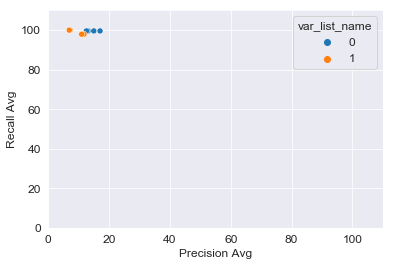

0:19:16.810556


In [41]:
clusters_prueba = param_tuning([0.4,0.7],[8,9],users,data,[vars_list,vars_list_1])

#### 3. Modelos Dbscan:

Se corren modelos para valores de eps bajos, medios y altos, en combinacion con valores de min_samples bajos, medios y altos,
para cada uno de los 11 grupos de variables seleccionados

In [26]:
eps_bajos = [0.4,0.7,0.9,1]
eps_medios= [1.2,1.5,1.6, 1.7]
eps_altos = [1.8, 1.9, 2, 2.1]

minS_bajos  = [3,4]
minS_medios = [5,6,7]
minS_altos  = [8,9]


BB = (eps_bajos,minS_bajos)
BM = (eps_bajos,minS_medios)
BA = (eps_bajos,minS_altos)
MB = (eps_medios,minS_bajos)
MM = (eps_medios,minS_medios)
MA = (eps_medios,minS_altos)
AB = (eps_altos,minS_bajos)
AM = (eps_altos,minS_medios)
AA = (eps_altos,minS_altos)

list_listvars=[vars_list,vars_list_1,vars_list_2,vars_list_3,vars_list_4,vars_list_5,vars_list_6,vars_list_7,vars_list_8,
               vars_list_9,vars_list_10]

0
eps=0.4 ; min_samples=3
FP Global: 9.57% | Accuracy: 89.89% | Fraudes atrapados: 65.6% | Recall Avg: 78.55% | Precision Avg: 18.23% | F1 Avg: 28.1

eps=0.4 ; min_samples=4
FP Global: 12.73% | Accuracy: 87.21% | Fraudes atrapados: 84.8% | Recall Avg: 90.85% | Precision Avg: 18.03% | F1 Avg: 28.14

eps=0.7 ; min_samples=3
FP Global: 6.24% | Accuracy: 92.95% | Fraudes atrapados: 56.8% | Recall Avg: 68.72% | Precision Avg: 21.35% | F1 Avg: 30.42

eps=0.7 ; min_samples=4
FP Global: 8.74% | Accuracy: 90.94% | Fraudes atrapados: 76.8% | Recall Avg: 82.65% | Precision Avg: 21.91% | F1 Avg: 31.72

eps=0.9 ; min_samples=3
FP Global: 4.57% | Accuracy: 94.49% | Fraudes atrapados: 52.8% | Recall Avg: 64.34% | Precision Avg: 23.84% | F1 Avg: 33.21

eps=0.9 ; min_samples=4
FP Global: 6.74% | Accuracy: 92.74% | Fraudes atrapados: 69.6% | Recall Avg: 77.05% | Precision Avg: 23.76% | F1 Avg: 33.66

eps=1 ; min_samples=3
FP Global: 3.2% | Accuracy: 95.81% | Fraudes atrapados: 52.0% | Recall Avg: 62.7% 

FP Global: 12.86% | Accuracy: 86.72% | Fraudes atrapados: 68.0% | Recall Avg: 79.1% | Precision Avg: 14.65% | F1 Avg: 23.16

eps=0.4 ; min_samples=4
FP Global: 18.18% | Accuracy: 81.93% | Fraudes atrapados: 87.2% | Recall Avg: 91.39% | Precision Avg: 12.18% | F1 Avg: 20.61

eps=0.7 ; min_samples=3
FP Global: 7.19% | Accuracy: 92.15% | Fraudes atrapados: 63.2% | Recall Avg: 71.72% | Precision Avg: 20.6% | F1 Avg: 29.53

eps=0.7 ; min_samples=4
FP Global: 9.59% | Accuracy: 90.2% | Fraudes atrapados: 80.8% | Recall Avg: 83.2% | Precision Avg: 20.35% | F1 Avg: 30.04

eps=0.9 ; min_samples=3
FP Global: 4.42% | Accuracy: 94.65% | Fraudes atrapados: 53.6% | Recall Avg: 62.7% | Precision Avg: 24.12% | F1 Avg: 33.33

eps=0.9 ; min_samples=4
FP Global: 6.12% | Accuracy: 93.35% | Fraudes atrapados: 69.6% | Recall Avg: 74.59% | Precision Avg: 24.38% | F1 Avg: 34.07

eps=1 ; min_samples=3
FP Global: 3.0% | Accuracy: 95.83% | Fraudes atrapados: 44.0% | Recall Avg: 56.15% | Precision Avg: 27.45% | F1

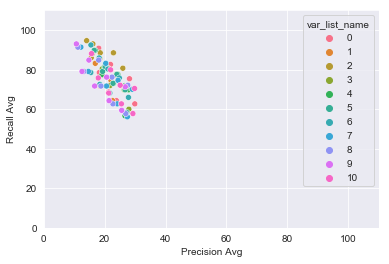

3:32:10.305068


In [35]:
clusters_BB = param_tuning(BB[0],BB[1],users,data,list_listvars)

0
eps=0.4 ; min_samples=5
FP Global: 15.7% | Accuracy: 84.61% | Fraudes atrapados: 98.4% | Recall Avg: 99.04% | Precision Avg: 18.42% | F1 Avg: 28.94

eps=0.4 ; min_samples=6
FP Global: 18.6% | Accuracy: 81.79% | Fraudes atrapados: 99.2% | Recall Avg: 99.59% | Precision Avg: 15.4% | F1 Avg: 25.05

eps=0.4 ; min_samples=7
FP Global: 21.08% | Accuracy: 79.37% | Fraudes atrapados: 99.2% | Recall Avg: 99.59% | Precision Avg: 13.53% | F1 Avg: 22.35

eps=0.7 ; min_samples=5
FP Global: 10.65% | Accuracy: 89.55% | Fraudes atrapados: 98.4% | Recall Avg: 99.04% | Precision Avg: 22.83% | F1 Avg: 34.26

eps=0.7 ; min_samples=6
FP Global: 12.52% | Accuracy: 87.74% | Fraudes atrapados: 99.2% | Recall Avg: 99.59% | Precision Avg: 19.35% | F1 Avg: 30.18

eps=0.7 ; min_samples=7
FP Global: 13.97% | Accuracy: 86.31% | Fraudes atrapados: 99.2% | Recall Avg: 99.59% | Precision Avg: 18.01% | F1 Avg: 28.24

eps=0.9 ; min_samples=5
FP Global: 8.08% | Accuracy: 91.89% | Fraudes atrapados: 90.4% | Recall Avg: 

FP Global: 9.1% | Accuracy: 90.87% | Fraudes atrapados: 89.6% | Recall Avg: 93.44% | Precision Avg: 21.86% | F1 Avg: 33.39

eps=0.9 ; min_samples=7
FP Global: 10.49% | Accuracy: 89.52% | Fraudes atrapados: 89.6% | Recall Avg: 93.44% | Precision Avg: 19.77% | F1 Avg: 30.76

eps=1 ; min_samples=5
FP Global: 5.74% | Accuracy: 94.02% | Fraudes atrapados: 83.2% | Recall Avg: 84.97% | Precision Avg: 31.55% | F1 Avg: 41.46

eps=1 ; min_samples=6
FP Global: 6.51% | Accuracy: 93.26% | Fraudes atrapados: 83.2% | Recall Avg: 84.97% | Precision Avg: 29.33% | F1 Avg: 39.18

eps=1 ; min_samples=7
FP Global: 8.27% | Accuracy: 91.56% | Fraudes atrapados: 84.0% | Recall Avg: 86.61% | Precision Avg: 25.72% | F1 Avg: 35.91

5
eps=0.4 ; min_samples=5
FP Global: 15.16% | Accuracy: 85.1% | Fraudes atrapados: 96.8% | Recall Avg: 97.95% | Precision Avg: 15.82% | F1 Avg: 25.88

eps=0.4 ; min_samples=6
FP Global: 19.23% | Accuracy: 81.13% | Fraudes atrapados: 96.8% | Recall Avg: 97.95% | Precision Avg: 12.06% |

FP Global: 14.39% | Accuracy: 85.89% | Fraudes atrapados: 98.4% | Recall Avg: 97.95% | Precision Avg: 14.68% | F1 Avg: 24.69

eps=0.7 ; min_samples=6
FP Global: 16.13% | Accuracy: 84.19% | Fraudes atrapados: 98.4% | Recall Avg: 97.95% | Precision Avg: 13.36% | F1 Avg: 22.81

eps=0.7 ; min_samples=7
FP Global: 18.65% | Accuracy: 81.72% | Fraudes atrapados: 98.4% | Recall Avg: 97.95% | Precision Avg: 11.74% | F1 Avg: 20.39

eps=0.9 ; min_samples=5
FP Global: 9.05% | Accuracy: 91.03% | Fraudes atrapados: 94.4% | Recall Avg: 93.44% | Precision Avg: 21.57% | F1 Avg: 33.2

eps=0.9 ; min_samples=6
FP Global: 10.58% | Accuracy: 89.55% | Fraudes atrapados: 95.2% | Recall Avg: 95.08% | Precision Avg: 19.14% | F1 Avg: 30.43

eps=0.9 ; min_samples=7
FP Global: 12.36% | Accuracy: 87.81% | Fraudes atrapados: 95.2% | Recall Avg: 95.08% | Precision Avg: 16.06% | F1 Avg: 26.59

eps=1 ; min_samples=5
FP Global: 6.65% | Accuracy: 93.26% | Fraudes atrapados: 89.6% | Recall Avg: 88.52% | Precision Avg: 28.

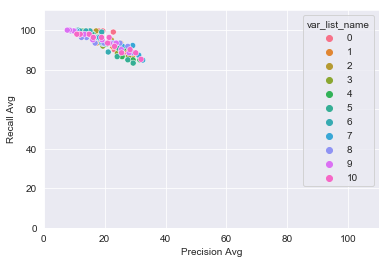

4:58:44.622668


In [36]:
clusters_BM = param_tuning(BM[0],BM[1],users,data,list_listvars)

0
eps=0.4 ; min_samples=8
FP Global: 22.7% | Accuracy: 77.78% | Fraudes atrapados: 99.2% | Recall Avg: 99.59% | Precision Avg: 13.18% | F1 Avg: 21.74

eps=0.4 ; min_samples=9
FP Global: 24.32% | Accuracy: 76.2% | Fraudes atrapados: 99.2% | Recall Avg: 99.59% | Precision Avg: 12.61% | F1 Avg: 20.83

eps=0.7 ; min_samples=8
FP Global: 15.92% | Accuracy: 84.42% | Fraudes atrapados: 99.2% | Recall Avg: 99.59% | Precision Avg: 17.07% | F1 Avg: 26.76

eps=0.7 ; min_samples=9
FP Global: 18.44% | Accuracy: 81.95% | Fraudes atrapados: 99.2% | Recall Avg: 99.59% | Precision Avg: 15.02% | F1 Avg: 24.36

eps=0.9 ; min_samples=8
FP Global: 11.38% | Accuracy: 88.76% | Fraudes atrapados: 95.2% | Recall Avg: 96.31% | Precision Avg: 19.56% | F1 Avg: 30.23

eps=0.9 ; min_samples=9
FP Global: 12.86% | Accuracy: 87.32% | Fraudes atrapados: 95.2% | Recall Avg: 96.31% | Precision Avg: 18.3% | F1 Avg: 28.41

eps=1 ; min_samples=8
FP Global: 9.05% | Accuracy: 90.99% | Fraudes atrapados: 92.8% | Recall Avg: 94

FP Global: 13.97% | Accuracy: 86.26% | Fraudes atrapados: 96.8% | Recall Avg: 97.95% | Precision Avg: 17.21% | F1 Avg: 27.68

7
eps=0.4 ; min_samples=8
FP Global: 31.98% | Accuracy: 68.72% | Fraudes atrapados: 100.0% | Recall Avg: 100.0% | Precision Avg: 8.03% | F1 Avg: 14.46

eps=0.4 ; min_samples=9
FP Global: 33.54% | Accuracy: 67.19% | Fraudes atrapados: 100.0% | Recall Avg: 100.0% | Precision Avg: 7.7% | F1 Avg: 13.89

eps=0.7 ; min_samples=8
FP Global: 17.07% | Accuracy: 83.27% | Fraudes atrapados: 98.4% | Recall Avg: 97.95% | Precision Avg: 13.23% | F1 Avg: 22.55

eps=0.7 ; min_samples=9
FP Global: 18.35% | Accuracy: 82.02% | Fraudes atrapados: 98.4% | Recall Avg: 97.95% | Precision Avg: 12.6% | F1 Avg: 21.59

eps=0.9 ; min_samples=8
FP Global: 11.21% | Accuracy: 88.95% | Fraudes atrapados: 96.0% | Recall Avg: 96.31% | Precision Avg: 18.71% | F1 Avg: 29.89

eps=0.9 ; min_samples=9
FP Global: 12.07% | Accuracy: 88.11% | Fraudes atrapados: 96.0% | Recall Avg: 96.31% | Precision Avg

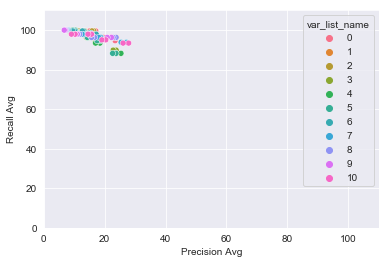

3:25:26.548787


In [37]:
clusters_BA = param_tuning(BA[0],BA[1],users,data,list_listvars)

0
eps=1.2 ; min_samples=3
FP Global: 2.19% | Accuracy: 96.53% | Fraudes atrapados: 40.0% | Recall Avg: 50.41% | Precision Avg: 31.6% | F1 Avg: 40.71

eps=1.2 ; min_samples=4
FP Global: 3.29% | Accuracy: 95.87% | Fraudes atrapados: 58.4% | Recall Avg: 65.57% | Precision Avg: 30.98% | F1 Avg: 41.76

eps=1.5 ; min_samples=3
FP Global: 1.04% | Accuracy: 97.38% | Fraudes atrapados: 27.2% | Recall Avg: 35.25% | Precision Avg: 40.69% | F1 Avg: 47.16

eps=1.5 ; min_samples=4
FP Global: 1.87% | Accuracy: 96.9% | Fraudes atrapados: 42.4% | Recall Avg: 50.41% | Precision Avg: 40.2% | F1 Avg: 49.17

eps=1.6 ; min_samples=3
FP Global: 0.68% | Accuracy: 97.61% | Fraudes atrapados: 21.6% | Recall Avg: 28.69% | Precision Avg: 45.24% | F1 Avg: 49.76

eps=1.6 ; min_samples=4
FP Global: 1.29% | Accuracy: 97.31% | Fraudes atrapados: 35.2% | Recall Avg: 41.8% | Precision Avg: 43.5% | F1 Avg: 50.88

eps=1.7 ; min_samples=3
FP Global: 0.45% | Accuracy: 97.75% | Fraudes atrapados: 17.6% | Recall Avg: 24.59% |

FP Global: 1.22% | Accuracy: 97.34% | Fraudes atrapados: 33.6% | Recall Avg: 40.98% | Precision Avg: 41.58% | F1 Avg: 50.9

7
eps=1.2 ; min_samples=3
FP Global: 1.56% | Accuracy: 97.12% | Fraudes atrapados: 38.4% | Recall Avg: 49.18% | Precision Avg: 40.51% | F1 Avg: 48.54

eps=1.2 ; min_samples=4
FP Global: 2.34% | Accuracy: 96.64% | Fraudes atrapados: 51.2% | Recall Avg: 60.25% | Precision Avg: 39.78% | F1 Avg: 48.82

eps=1.5 ; min_samples=3
FP Global: 0.65% | Accuracy: 97.75% | Fraudes atrapados: 26.4% | Recall Avg: 33.61% | Precision Avg: 51.13% | F1 Avg: 57.4

eps=1.5 ; min_samples=4
FP Global: 0.81% | Accuracy: 97.85% | Fraudes atrapados: 38.4% | Recall Avg: 45.08% | Precision Avg: 55.0% | F1 Avg: 62.97

eps=1.6 ; min_samples=3
FP Global: 0.45% | Accuracy: 97.85% | Fraudes atrapados: 22.4% | Recall Avg: 29.51% | Precision Avg: 60.24% | F1 Avg: 67.96

eps=1.6 ; min_samples=4
FP Global: 0.63% | Accuracy: 97.94% | Fraudes atrapados: 34.4% | Recall Avg: 41.8% | Precision Avg: 63.39% 

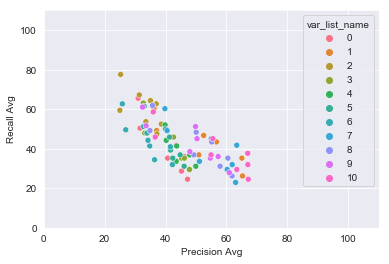

3:20:42.071180


In [38]:
clusters_MB = param_tuning(MB[0],MB[1],users,data,list_listvars)

0
eps=1.2 ; min_samples=5
FP Global: 4.26% | Accuracy: 95.43% | Fraudes atrapados: 81.6% | Recall Avg: 81.97% | Precision Avg: 33.46% | F1 Avg: 45.59

eps=1.2 ; min_samples=6
FP Global: 5.27% | Accuracy: 94.49% | Fraudes atrapados: 84.0% | Recall Avg: 85.25% | Precision Avg: 29.85% | F1 Avg: 41.77

eps=1.2 ; min_samples=7
FP Global: 6.42% | Accuracy: 93.4% | Fraudes atrapados: 85.6% | Recall Avg: 87.43% | Precision Avg: 28.5% | F1 Avg: 39.16

eps=1.5 ; min_samples=5
FP Global: 2.19% | Accuracy: 97.13% | Fraudes atrapados: 67.2% | Recall Avg: 67.35% | Precision Avg: 46.31% | F1 Avg: 55.8

eps=1.5 ; min_samples=6
FP Global: 2.73% | Accuracy: 96.75% | Fraudes atrapados: 73.6% | Recall Avg: 74.73% | Precision Avg: 42.79% | F1 Avg: 53.02

eps=1.5 ; min_samples=7
FP Global: 3.35% | Accuracy: 96.22% | Fraudes atrapados: 76.8% | Recall Avg: 79.64% | Precision Avg: 42.19% | F1 Avg: 52.57

eps=1.6 ; min_samples=5
FP Global: 1.58% | Accuracy: 97.5% | Fraudes atrapados: 56.8% | Recall Avg: 57.1% |

FP Global: 2.16% | Accuracy: 97.04% | Fraudes atrapados: 61.6% | Recall Avg: 63.93% | Precision Avg: 41.74% | F1 Avg: 51.93

eps=1.6 ; min_samples=7
FP Global: 2.59% | Accuracy: 96.78% | Fraudes atrapados: 68.8% | Recall Avg: 72.13% | Precision Avg: 42.87% | F1 Avg: 53.96

eps=1.7 ; min_samples=5
FP Global: 0.95% | Accuracy: 97.96% | Fraudes atrapados: 49.6% | Recall Avg: 48.36% | Precision Avg: 53.33% | F1 Avg: 61.6

eps=1.7 ; min_samples=6
FP Global: 1.49% | Accuracy: 97.52% | Fraudes atrapados: 53.6% | Recall Avg: 54.92% | Precision Avg: 46.85% | F1 Avg: 54.6

eps=1.7 ; min_samples=7
FP Global: 2.05% | Accuracy: 97.2% | Fraudes atrapados: 64.0% | Recall Avg: 66.39% | Precision Avg: 48.22% | F1 Avg: 57.56

5
eps=1.2 ; min_samples=5
FP Global: 3.62% | Accuracy: 95.97% | Fraudes atrapados: 77.6% | Recall Avg: 81.15% | Precision Avg: 38.88% | F1 Avg: 49.67

eps=1.2 ; min_samples=6
FP Global: 4.12% | Accuracy: 95.51% | Fraudes atrapados: 79.2% | Recall Avg: 82.79% | Precision Avg: 36.84%

FP Global: 1.67% | Accuracy: 97.54% | Fraudes atrapados: 62.4% | Recall Avg: 63.52% | Precision Avg: 50.82% | F1 Avg: 59.16

eps=1.5 ; min_samples=6
FP Global: 1.91% | Accuracy: 97.36% | Fraudes atrapados: 64.8% | Recall Avg: 66.8% | Precision Avg: 50.83% | F1 Avg: 59.89

eps=1.5 ; min_samples=7
FP Global: 2.43% | Accuracy: 96.96% | Fraudes atrapados: 69.6% | Recall Avg: 71.72% | Precision Avg: 49.6% | F1 Avg: 59.41

eps=1.6 ; min_samples=5
FP Global: 1.19% | Accuracy: 97.84% | Fraudes atrapados: 54.4% | Recall Avg: 56.56% | Precision Avg: 52.1% | F1 Avg: 59.5

eps=1.6 ; min_samples=6
FP Global: 1.33% | Accuracy: 97.7% | Fraudes atrapados: 54.4% | Recall Avg: 56.56% | Precision Avg: 48.93% | F1 Avg: 55.99

eps=1.6 ; min_samples=7
FP Global: 1.85% | Accuracy: 97.38% | Fraudes atrapados: 63.2% | Recall Avg: 65.57% | Precision Avg: 48.18% | F1 Avg: 57.57

eps=1.7 ; min_samples=5
FP Global: 0.81% | Accuracy: 98.08% | Fraudes atrapados: 48.8% | Recall Avg: 47.54% | Precision Avg: 60.86% | F

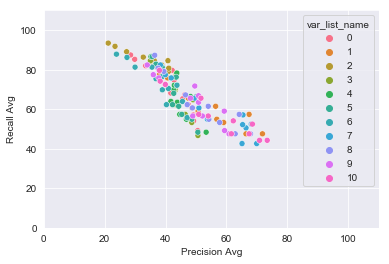

8:52:52.160348


In [39]:
clusters_MM = param_tuning(MM[0],MM[1],users,data,list_listvars)

0
eps=1.2 ; min_samples=8
FP Global: 7.03% | Accuracy: 92.86% | Fraudes atrapados: 88.0% | Recall Avg: 90.71% | Precision Avg: 28.2% | F1 Avg: 38.96

eps=1.2 ; min_samples=9
FP Global: 7.54% | Accuracy: 92.37% | Fraudes atrapados: 88.0% | Recall Avg: 90.71% | Precision Avg: 27.6% | F1 Avg: 38.09

eps=1.5 ; min_samples=8
FP Global: 3.58% | Accuracy: 96.01% | Fraudes atrapados: 77.6% | Recall Avg: 81.28% | Precision Avg: 40.95% | F1 Avg: 51.2

eps=1.5 ; min_samples=9
FP Global: 4.12% | Accuracy: 95.48% | Fraudes atrapados: 77.6% | Recall Avg: 81.28% | Precision Avg: 38.64% | F1 Avg: 48.92

eps=1.6 ; min_samples=8
FP Global: 3.18% | Accuracy: 96.27% | Fraudes atrapados: 72.0% | Recall Avg: 75.96% | Precision Avg: 41.94% | F1 Avg: 51.27

eps=1.6 ; min_samples=9
FP Global: 3.65% | Accuracy: 95.83% | Fraudes atrapados: 72.8% | Recall Avg: 77.6% | Precision Avg: 41.2% | F1 Avg: 50.53

eps=1.7 ; min_samples=8
FP Global: 2.5% | Accuracy: 96.82% | Fraudes atrapados: 66.4% | Recall Avg: 72.13% | 

FP Global: 3.56% | Accuracy: 95.99% | Fraudes atrapados: 76.0% | Recall Avg: 80.33% | Precision Avg: 41.88% | F1 Avg: 53.43

7
eps=1.2 ; min_samples=8
FP Global: 4.66% | Accuracy: 95.06% | Fraudes atrapados: 82.4% | Recall Avg: 84.02% | Precision Avg: 37.84% | F1 Avg: 48.98

eps=1.2 ; min_samples=9
FP Global: 5.36% | Accuracy: 94.37% | Fraudes atrapados: 82.4% | Recall Avg: 84.02% | Precision Avg: 35.25% | F1 Avg: 46.17

eps=1.5 ; min_samples=8
FP Global: 2.0% | Accuracy: 97.43% | Fraudes atrapados: 72.0% | Recall Avg: 75.41% | Precision Avg: 53.98% | F1 Avg: 65.28

eps=1.5 ; min_samples=9
FP Global: 2.34% | Accuracy: 97.1% | Fraudes atrapados: 72.0% | Recall Avg: 75.41% | Precision Avg: 51.41% | F1 Avg: 62.23

eps=1.6 ; min_samples=8
FP Global: 1.06% | Accuracy: 98.03% | Fraudes atrapados: 57.6% | Recall Avg: 60.38% | Precision Avg: 62.42% | F1 Avg: 68.73

eps=1.6 ; min_samples=9
FP Global: 1.51% | Accuracy: 97.71% | Fraudes atrapados: 63.2% | Recall Avg: 65.3% | Precision Avg: 58.49%

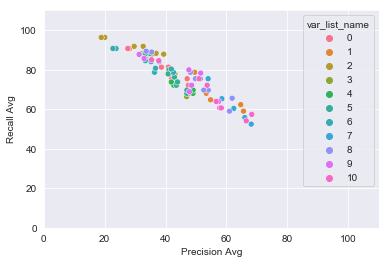

3:30:13.748472


In [28]:
clusters_MA = param_tuning(MA[0],MA[1],users,data,list_listvars)

0
eps=1.8 ; min_samples=3
FP Global: 0.31% | Accuracy: 97.85% | Fraudes atrapados: 16.0% | Recall Avg: 21.31% | Precision Avg: 52.78% | F1 Avg: 59.08

eps=1.8 ; min_samples=4
FP Global: 0.61% | Accuracy: 97.73% | Fraudes atrapados: 24.0% | Recall Avg: 30.33% | Precision Avg: 53.26% | F1 Avg: 61.83

eps=1.9 ; min_samples=3
FP Global: 0.2% | Accuracy: 97.94% | Fraudes atrapados: 15.2% | Recall Avg: 19.67% | Precision Avg: 64.44% | F1 Avg: 69.78

eps=1.9 ; min_samples=4
FP Global: 0.49% | Accuracy: 97.85% | Fraudes atrapados: 24.0% | Recall Avg: 30.33% | Precision Avg: 62.58% | F1 Avg: 71.35

eps=2 ; min_samples=3
FP Global: 0.11% | Accuracy: 97.89% | Fraudes atrapados: 8.8% | Recall Avg: 11.48% | Precision Avg: 66.67% | F1 Avg: 70.37

eps=2 ; min_samples=4
FP Global: 0.34% | Accuracy: 97.75% | Fraudes atrapados: 12.8% | Recall Avg: 18.03% | Precision Avg: 55.73% | F1 Avg: 58.13

eps=2.1 ; min_samples=3
FP Global: 0.11% | Accuracy: 97.85% | Fraudes atrapados: 7.2% | Recall Avg: 9.84% | Pr

FP Global: 0.04% | Accuracy: 98.07% | Fraudes atrapados: 13.6% | Recall Avg: 18.03% | Precision Avg: 90.91% | F1 Avg: 93.94

eps=1.8 ; min_samples=4
FP Global: 0.18% | Accuracy: 98.01% | Fraudes atrapados: 17.6% | Recall Avg: 24.59% | Precision Avg: 77.08% | F1 Avg: 82.08

eps=1.9 ; min_samples=3
FP Global: 0.04% | Accuracy: 97.94% | Fraudes atrapados: 8.0% | Recall Avg: 11.48% | Precision Avg: 85.71% | F1 Avg: 90.48

eps=1.9 ; min_samples=4
FP Global: 0.05% | Accuracy: 97.98% | Fraudes atrapados: 10.4% | Recall Avg: 14.75% | Precision Avg: 85.19% | F1 Avg: 90.37

eps=2 ; min_samples=3
FP Global: 0.04% | Accuracy: 97.87% | Fraudes atrapados: 4.8% | Recall Avg: 8.2% | Precision Avg: 80.0% | F1 Avg: 86.67

eps=2 ; min_samples=4
FP Global: 0.04% | Accuracy: 97.89% | Fraudes atrapados: 5.6% | Recall Avg: 9.02% | Precision Avg: 83.33% | F1 Avg: 83.34

eps=2.1 ; min_samples=3
FP Global: 0.04% | Accuracy: 97.87% | Fraudes atrapados: 4.8% | Recall Avg: 8.2% | Precision Avg: 80.0% | F1 Avg: 86.

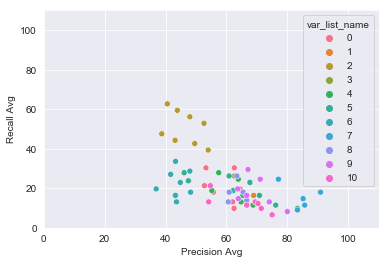

3:14:15.821578


In [29]:
clusters_AB = param_tuning(AB[0],AB[1],users,data,list_listvars)

0
eps=1.8 ; min_samples=5
FP Global: 0.76% | Accuracy: 97.96% | Fraudes atrapados: 40.8% | Recall Avg: 41.8% | Precision Avg: 58.79% | F1 Avg: 67.02

eps=1.8 ; min_samples=6
FP Global: 1.06% | Accuracy: 97.73% | Fraudes atrapados: 44.0% | Recall Avg: 46.72% | Precision Avg: 56.88% | F1 Avg: 65.25

eps=1.8 ; min_samples=7
FP Global: 1.29% | Accuracy: 97.68% | Fraudes atrapados: 52.0% | Recall Avg: 54.37% | Precision Avg: 61.2% | F1 Avg: 69.02

eps=1.9 ; min_samples=5
FP Global: 0.63% | Accuracy: 97.99% | Fraudes atrapados: 36.8% | Recall Avg: 38.52% | Precision Avg: 63.4% | F1 Avg: 72.41

eps=1.9 ; min_samples=6
FP Global: 0.81% | Accuracy: 97.84% | Fraudes atrapados: 37.6% | Recall Avg: 40.16% | Precision Avg: 62.05% | F1 Avg: 70.82

eps=1.9 ; min_samples=7
FP Global: 0.86% | Accuracy: 97.85% | Fraudes atrapados: 40.8% | Recall Avg: 43.44% | Precision Avg: 62.98% | F1 Avg: 71.72

eps=2 ; min_samples=5
FP Global: 0.45% | Accuracy: 97.96% | Fraudes atrapados: 27.2% | Recall Avg: 27.87% |

FP Global: 0.61% | Accuracy: 98.12% | Fraudes atrapados: 41.6% | Recall Avg: 40.98% | Precision Avg: 62.59% | F1 Avg: 69.58

eps=2.1 ; min_samples=5
FP Global: 0.18% | Accuracy: 98.08% | Fraudes atrapados: 20.8% | Recall Avg: 21.31% | Precision Avg: 65.56% | F1 Avg: 72.22

eps=2.1 ; min_samples=6
FP Global: 0.34% | Accuracy: 97.96% | Fraudes atrapados: 22.4% | Recall Avg: 23.77% | Precision Avg: 61.3% | F1 Avg: 65.74

eps=2.1 ; min_samples=7
FP Global: 0.34% | Accuracy: 97.99% | Fraudes atrapados: 24.0% | Recall Avg: 25.41% | Precision Avg: 63.33% | F1 Avg: 67.54

5
eps=1.8 ; min_samples=5
FP Global: 0.7% | Accuracy: 97.98% | Fraudes atrapados: 39.2% | Recall Avg: 39.34% | Precision Avg: 55.86% | F1 Avg: 61.95

eps=1.8 ; min_samples=6
FP Global: 0.86% | Accuracy: 97.84% | Fraudes atrapados: 40.0% | Recall Avg: 40.98% | Precision Avg: 53.44% | F1 Avg: 59.81

eps=1.8 ; min_samples=7
FP Global: 1.26% | Accuracy: 97.63% | Fraudes atrapados: 48.0% | Recall Avg: 49.18% | Precision Avg: 52.44

FP Global: 0.41% | Accuracy: 98.05% | Fraudes atrapados: 29.6% | Recall Avg: 30.33% | Precision Avg: 65.95% | F1 Avg: 72.62

eps=1.9 ; min_samples=7
FP Global: 0.41% | Accuracy: 98.1% | Fraudes atrapados: 32.0% | Recall Avg: 33.61% | Precision Avg: 68.91% | F1 Avg: 75.0

eps=2 ; min_samples=5
FP Global: 0.22% | Accuracy: 98.05% | Fraudes atrapados: 20.8% | Recall Avg: 22.95% | Precision Avg: 72.22% | F1 Avg: 78.67

eps=2 ; min_samples=6
FP Global: 0.23% | Accuracy: 98.05% | Fraudes atrapados: 21.6% | Recall Avg: 23.5% | Precision Avg: 69.61% | F1 Avg: 72.35

eps=2 ; min_samples=7
FP Global: 0.23% | Accuracy: 98.05% | Fraudes atrapados: 21.6% | Recall Avg: 23.5% | Precision Avg: 69.61% | F1 Avg: 72.35

eps=2.1 ; min_samples=5
FP Global: 0.11% | Accuracy: 97.98% | Fraudes atrapados: 12.8% | Recall Avg: 13.11% | Precision Avg: 72.22% | F1 Avg: 77.78

eps=2.1 ; min_samples=6
FP Global: 0.11% | Accuracy: 98.01% | Fraudes atrapados: 14.4% | Recall Avg: 14.48% | Precision Avg: 77.27% | F1 Avg

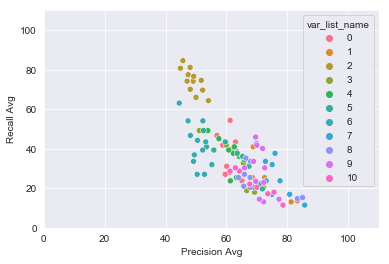

5:00:03.583963


In [30]:
clusters_AM = param_tuning(AM[0],AM[1],users,data,list_listvars)

0
eps=1.8 ; min_samples=8
FP Global: 1.91% | Accuracy: 97.26% | Fraudes atrapados: 60.0% | Recall Avg: 65.03% | Precision Avg: 56.01% | F1 Avg: 64.11

eps=1.8 ; min_samples=9
FP Global: 2.25% | Accuracy: 96.96% | Fraudes atrapados: 61.6% | Recall Avg: 67.49% | Precision Avg: 52.2% | F1 Avg: 60.87

eps=1.9 ; min_samples=8
FP Global: 1.31% | Accuracy: 97.59% | Fraudes atrapados: 48.8% | Recall Avg: 51.09% | Precision Avg: 57.34% | F1 Avg: 66.36

eps=1.9 ; min_samples=9
FP Global: 1.53% | Accuracy: 97.47% | Fraudes atrapados: 52.8% | Recall Avg: 56.83% | Precision Avg: 53.86% | F1 Avg: 64.48

eps=2 ; min_samples=8
FP Global: 0.83% | Accuracy: 97.82% | Fraudes atrapados: 37.6% | Recall Avg: 37.7% | Precision Avg: 56.93% | F1 Avg: 63.31

eps=2 ; min_samples=9
FP Global: 1.13% | Accuracy: 97.7% | Fraudes atrapados: 45.6% | Recall Avg: 46.72% | Precision Avg: 58.0% | F1 Avg: 64.33

eps=2.1 ; min_samples=8
FP Global: 0.65% | Accuracy: 97.87% | Fraudes atrapados: 32.0% | Recall Avg: 31.97% | Pr

FP Global: 0.29% | Accuracy: 98.35% | Fraudes atrapados: 37.6% | Recall Avg: 40.57% | Precision Avg: 77.68% | F1 Avg: 80.29

eps=1.8 ; min_samples=9
FP Global: 0.32% | Accuracy: 98.38% | Fraudes atrapados: 40.8% | Recall Avg: 43.85% | Precision Avg: 77.5% | F1 Avg: 80.49

eps=1.9 ; min_samples=8
FP Global: 0.16% | Accuracy: 98.14% | Fraudes atrapados: 22.4% | Recall Avg: 23.77% | Precision Avg: 73.04% | F1 Avg: 77.4

eps=1.9 ; min_samples=9
FP Global: 0.16% | Accuracy: 98.14% | Fraudes atrapados: 22.4% | Recall Avg: 23.77% | Precision Avg: 73.04% | F1 Avg: 77.4

eps=2 ; min_samples=8
FP Global: 0.11% | Accuracy: 98.05% | Fraudes atrapados: 16.0% | Recall Avg: 16.94% | Precision Avg: 75.0% | F1 Avg: 70.24

eps=2 ; min_samples=9
FP Global: 0.11% | Accuracy: 98.05% | Fraudes atrapados: 16.0% | Recall Avg: 16.94% | Precision Avg: 75.0% | F1 Avg: 70.24

eps=2.1 ; min_samples=8
FP Global: 0.04% | Accuracy: 98.03% | Fraudes atrapados: 12.0% | Recall Avg: 12.02% | Precision Avg: 87.5% | F1 Avg

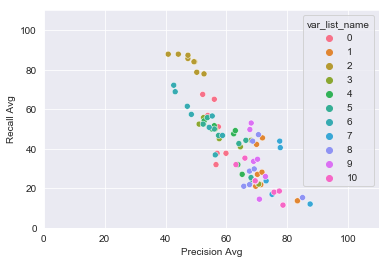

3:16:26.904902


In [31]:
clusters_AA = param_tuning(AA[0],AA[1],users,data,list_listvars)

#### 4. Estimación del impacto del modelo:

4.1. Estimacion de ganancias del modelo seleccionado

    El modelo seleccionado es: grupo de variables 1, eps = 1,7 y min_samples = 9
    db_scan(eps,min_samples,user_id, data, vars_list,output="Y")



 DBSCAN FOR USER 150073 

Data
 - Cantidad de observaciones        : 195
 - Cantidad de observaciones fraude : 1

Clusters Info
 - class 0: number of points 191
 - class -1: number of points 4
 - TFP: 1.55% | Accuracy: 98.46% | Recall: 100.0%  | Precision: 25.0% | F1: 40.0%
 - Conf Matrix:


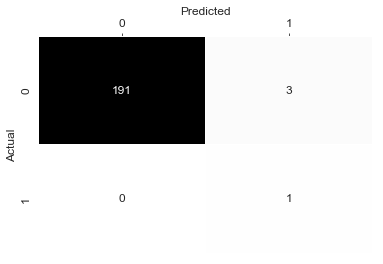



 DBSCAN FOR USER 2109180 

Data
 - Cantidad de observaciones        : 85
 - Cantidad de observaciones fraude : 2

Clusters Info
 - class 0: number of points 83
 - class -1: number of points 2
 - TFP: 0.0% | Accuracy: 100.0% | Recall: 100.0%  | Precision: 100.0% | F1: 100.0%
 - Conf Matrix:


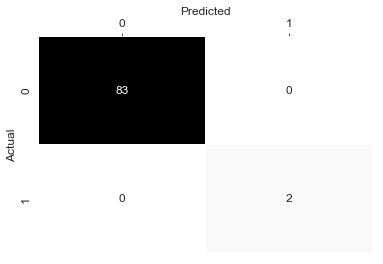



 DBSCAN FOR USER 2400976 

Data
 - Cantidad de observaciones        : 60
 - Cantidad de observaciones fraude : 2

Clusters Info
 - class 0: number of points 58
 - class -1: number of points 2
 - TFP: 0.0% | Accuracy: 100.0% | Recall: 100.0%  | Precision: 100.0% | F1: 100.0%
 - Conf Matrix:


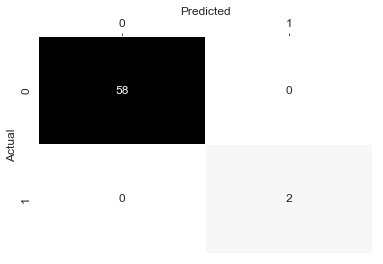



 DBSCAN FOR USER 2586765 

Data
 - Cantidad de observaciones        : 167
 - Cantidad de observaciones fraude : 1

Clusters Info
 - class 0: number of points 165
 - class -1: number of points 2
 - TFP: 0.6% | Accuracy: 99.4% | Recall: 100.0%  | Precision: 50.0% | F1: 66.67%
 - Conf Matrix:


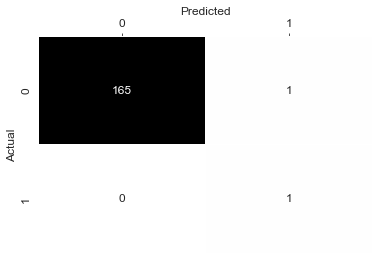



 DBSCAN FOR USER 2778561 

Data
 - Cantidad de observaciones        : 85
 - Cantidad de observaciones fraude : 2

Clusters Info
 - class 0: number of points 82
 - class -1: number of points 3
 - TFP: 1.2% | Accuracy: 98.82% | Recall: 100.0%  | Precision: 66.67% | F1: 80.0%
 - Conf Matrix:


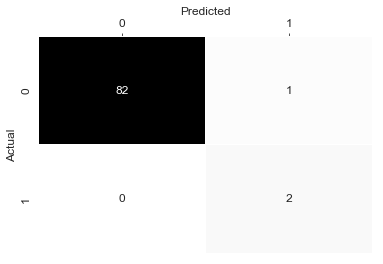



 DBSCAN FOR USER 2827296 

Data
 - Cantidad de observaciones        : 79
 - Cantidad de observaciones fraude : 2

Clusters Info
 - class 0: number of points 77
 - class -1: number of points 2
 - TFP: 0.0% | Accuracy: 100.0% | Recall: 100.0%  | Precision: 100.0% | F1: 100.0%
 - Conf Matrix:


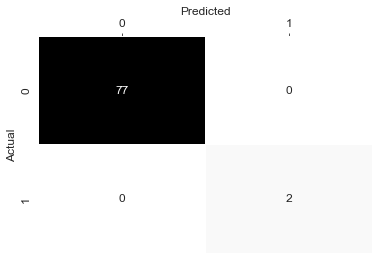



 DBSCAN FOR USER 2868203 

Data
 - Cantidad de observaciones        : 138
 - Cantidad de observaciones fraude : 4

Clusters Info
 - class 0: number of points 134
 - class -1: number of points 4
 - TFP: 0.0% | Accuracy: 100.0% | Recall: 100.0%  | Precision: 100.0% | F1: 100.0%
 - Conf Matrix:


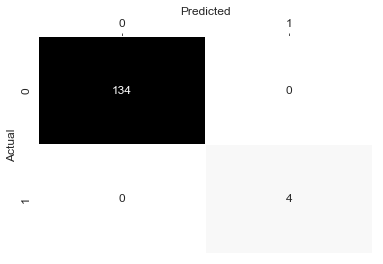



 DBSCAN FOR USER 2883110 

Data
 - Cantidad de observaciones        : 41
 - Cantidad de observaciones fraude : 4

Clusters Info
 - class 0: number of points 37
 - class -1: number of points 4
 - TFP: 0.0% | Accuracy: 100.0% | Recall: 100.0%  | Precision: 100.0% | F1: 100.0%
 - Conf Matrix:


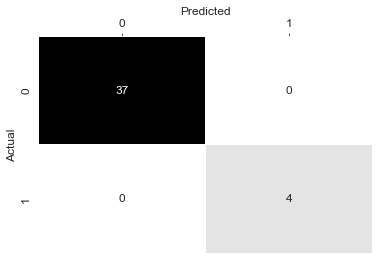



 DBSCAN FOR USER 3042723 

Data
 - Cantidad de observaciones        : 158
 - Cantidad de observaciones fraude : 3

Clusters Info
 - class 0: number of points 148
 - class -1: number of points 10
 - TFP: 4.52% | Accuracy: 95.57% | Recall: 100.0%  | Precision: 30.0% | F1: 46.15%
 - Conf Matrix:


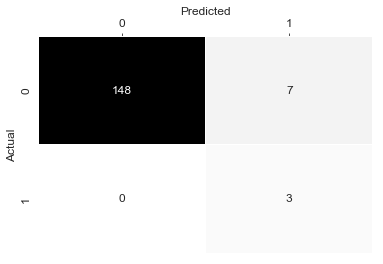



 DBSCAN FOR USER 3045671 

Data
 - Cantidad de observaciones        : 141
 - Cantidad de observaciones fraude : 1

Clusters Info
 - class 0: number of points 136
 - class -1: number of points 5
 - TFP: 2.86% | Accuracy: 97.16% | Recall: 100.0%  | Precision: 20.0% | F1: 33.33%
 - Conf Matrix:


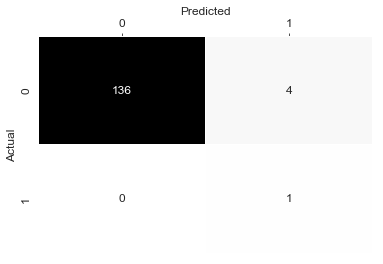



 DBSCAN FOR USER 3068918 

Data
 - Cantidad de observaciones        : 161
 - Cantidad de observaciones fraude : 3

Clusters Info
 - class 0: number of points 161
 - TFP: 0.0% | Accuracy: 98.14% | Recall: 0.0%  | Precision: X% | F1: X%
 - Conf Matrix:


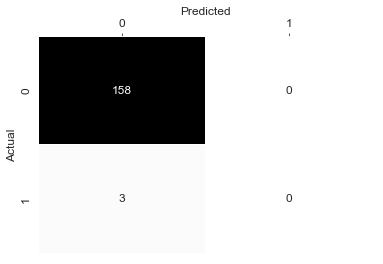



 DBSCAN FOR USER 3114938 

Data
 - Cantidad de observaciones        : 83
 - Cantidad de observaciones fraude : 2

Clusters Info
 - class 0: number of points 83
 - TFP: 0.0% | Accuracy: 97.59% | Recall: 0.0%  | Precision: X% | F1: X%
 - Conf Matrix:


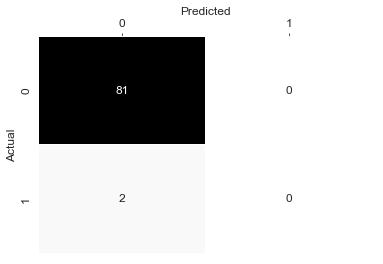



 DBSCAN FOR USER 3221106 

Data
 - Cantidad de observaciones        : 41
 - Cantidad de observaciones fraude : 1

Clusters Info
 - class 0: number of points 40
 - class -1: number of points 1
 - TFP: 0.0% | Accuracy: 100.0% | Recall: 100.0%  | Precision: 100.0% | F1: 100.0%
 - Conf Matrix:


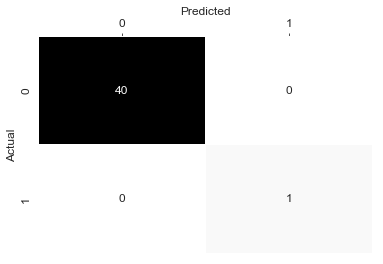



 DBSCAN FOR USER 3408431 

Data
 - Cantidad de observaciones        : 39
 - Cantidad de observaciones fraude : 3

Clusters Info
 - class 0: number of points 39
 - TFP: 0.0% | Accuracy: 92.31% | Recall: 0.0%  | Precision: X% | F1: X%
 - Conf Matrix:


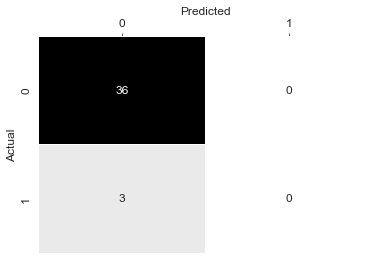



 DBSCAN FOR USER 3437770 

Data
 - Cantidad de observaciones        : 142
 - Cantidad de observaciones fraude : 4

Clusters Info
 - class 0: number of points 142
 - TFP: 0.0% | Accuracy: 97.18% | Recall: 0.0%  | Precision: X% | F1: X%
 - Conf Matrix:


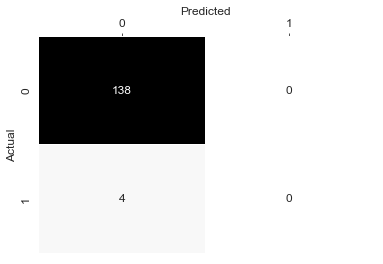



 DBSCAN FOR USER 3617729 

Data
 - Cantidad de observaciones        : 146
 - Cantidad de observaciones fraude : 2

Clusters Info
 - class 0: number of points 143
 - class -1: number of points 3
 - TFP: 0.69% | Accuracy: 99.32% | Recall: 100.0%  | Precision: 66.67% | F1: 80.0%
 - Conf Matrix:


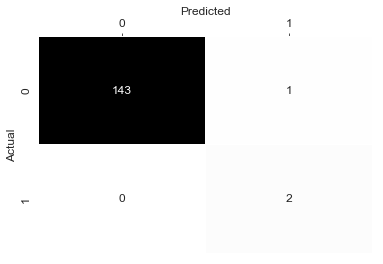



 DBSCAN FOR USER 3618455 

Data
 - Cantidad de observaciones        : 42
 - Cantidad de observaciones fraude : 2

Clusters Info
 - class 0: number of points 39
 - class -1: number of points 3
 - TFP: 2.5% | Accuracy: 97.62% | Recall: 100.0%  | Precision: 66.67% | F1: 80.0%
 - Conf Matrix:


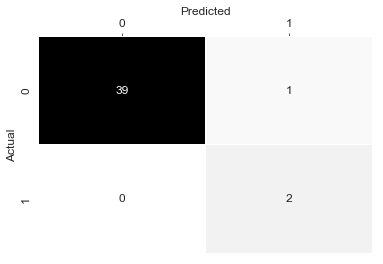



 DBSCAN FOR USER 3725780 

Data
 - Cantidad de observaciones        : 158
 - Cantidad de observaciones fraude : 2

Clusters Info
 - class 0: number of points 156
 - class -1: number of points 2
 - TFP: 0.0% | Accuracy: 100.0% | Recall: 100.0%  | Precision: 100.0% | F1: 100.0%
 - Conf Matrix:


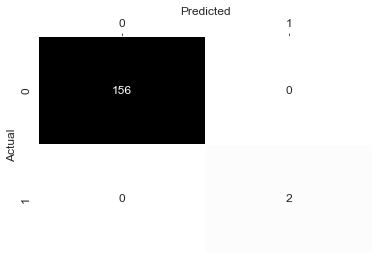



 DBSCAN FOR USER 37553 

Data
 - Cantidad de observaciones        : 63
 - Cantidad de observaciones fraude : 2

Clusters Info
 - class 0: number of points 62
 - class -1: number of points 1
 - TFP: 1.64% | Accuracy: 95.24% | Recall: 0.0%  | Precision: 0.0% | F1: 0.0%
 - Conf Matrix:


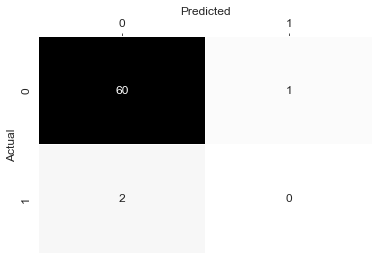



 DBSCAN FOR USER 3774558 

Data
 - Cantidad de observaciones        : 29
 - Cantidad de observaciones fraude : 1

Clusters Info
 - class 0: number of points 29
 - TFP: 0.0% | Accuracy: 96.55% | Recall: 0.0%  | Precision: X% | F1: X%
 - Conf Matrix:


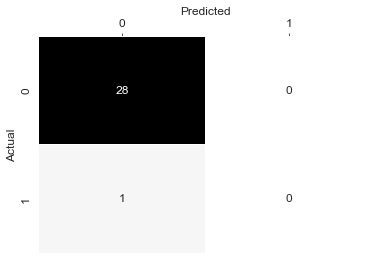



 DBSCAN FOR USER 3782790 

Data
 - Cantidad de observaciones        : 176
 - Cantidad de observaciones fraude : 3

Clusters Info
 - class 0: number of points 176
 - TFP: 0.0% | Accuracy: 98.3% | Recall: 0.0%  | Precision: X% | F1: X%
 - Conf Matrix:


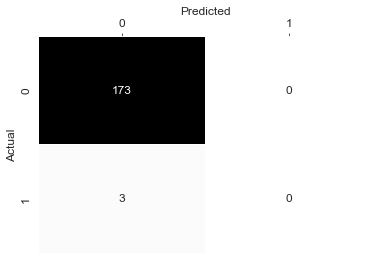



 DBSCAN FOR USER 3800237 

Data
 - Cantidad de observaciones        : 74
 - Cantidad de observaciones fraude : 1

Clusters Info
 - class 0: number of points 74
 - TFP: 0.0% | Accuracy: 98.65% | Recall: 0.0%  | Precision: X% | F1: X%
 - Conf Matrix:


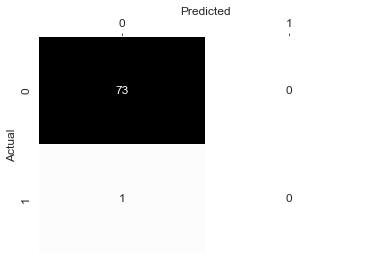



 DBSCAN FOR USER 3924958 

Data
 - Cantidad de observaciones        : 85
 - Cantidad de observaciones fraude : 2

Clusters Info
 - class 0: number of points 85
 - TFP: 0.0% | Accuracy: 97.65% | Recall: 0.0%  | Precision: X% | F1: X%
 - Conf Matrix:


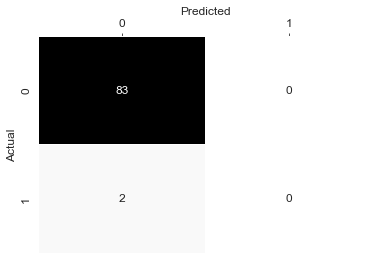



 DBSCAN FOR USER 3935173 

Data
 - Cantidad de observaciones        : 190
 - Cantidad de observaciones fraude : 2

Clusters Info
 - class 0: number of points 188
 - class -1: number of points 2
 - TFP: 0.0% | Accuracy: 100.0% | Recall: 100.0%  | Precision: 100.0% | F1: 100.0%
 - Conf Matrix:


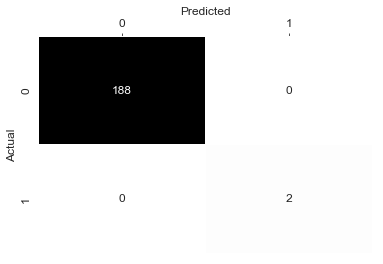



 DBSCAN FOR USER 3984473 

Data
 - Cantidad de observaciones        : 93
 - Cantidad de observaciones fraude : 3

Clusters Info
 - class 0: number of points 93
 - TFP: 0.0% | Accuracy: 96.77% | Recall: 0.0%  | Precision: X% | F1: X%
 - Conf Matrix:


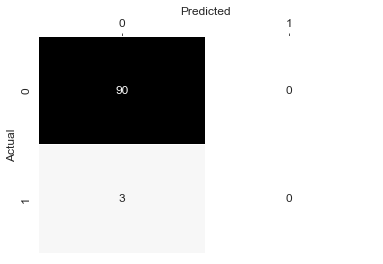



 DBSCAN FOR USER 4170942 

Data
 - Cantidad de observaciones        : 183
 - Cantidad de observaciones fraude : 2

Clusters Info
 - class 0: number of points 179
 - class -1: number of points 4
 - TFP: 1.1% | Accuracy: 98.91% | Recall: 100.0%  | Precision: 50.0% | F1: 66.67%
 - Conf Matrix:


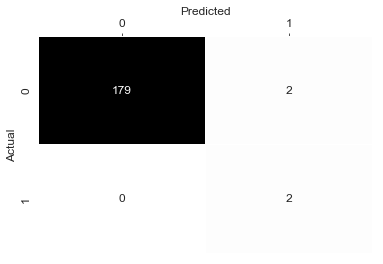



 DBSCAN FOR USER 4225979 

Data
 - Cantidad de observaciones        : 80
 - Cantidad de observaciones fraude : 2

Clusters Info
 - class 0: number of points 80
 - TFP: 0.0% | Accuracy: 97.5% | Recall: 0.0%  | Precision: X% | F1: X%
 - Conf Matrix:


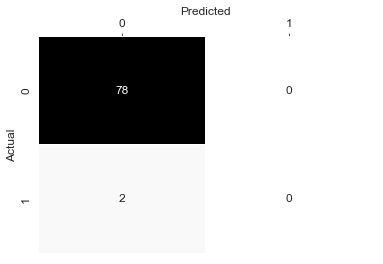



 DBSCAN FOR USER 4285617 

Data
 - Cantidad de observaciones        : 126
 - Cantidad de observaciones fraude : 1

Clusters Info
 - class 0: number of points 116
 - class 1: number of points 9
 - class -1: number of points 1
 - TFP: 0.0% | Accuracy: 100.0% | Recall: 100.0%  | Precision: 100.0% | F1: 100.0%
 - Conf Matrix:


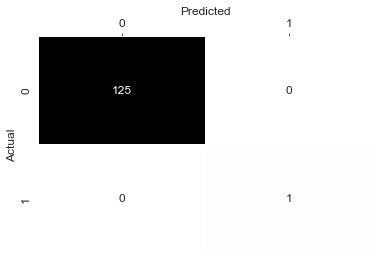



 DBSCAN FOR USER 4289041 

Data
 - Cantidad de observaciones        : 26
 - Cantidad de observaciones fraude : 4

Clusters Info
 - class 0: number of points 21
 - class -1: number of points 5
 - TFP: 22.73% | Accuracy: 65.38% | Recall: 0.0%  | Precision: 0.0% | F1: 0.0%
 - Conf Matrix:


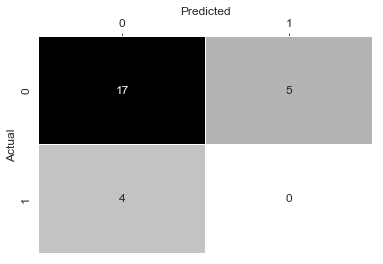



 DBSCAN FOR USER 4289668 

Data
 - Cantidad de observaciones        : 362
 - Cantidad de observaciones fraude : 2

Clusters Info
 - class 0: number of points 359
 - class -1: number of points 3
 - TFP: 0.28% | Accuracy: 99.72% | Recall: 100.0%  | Precision: 66.67% | F1: 80.0%
 - Conf Matrix:


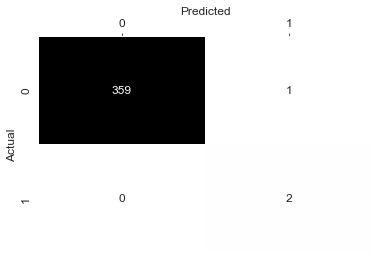



 DBSCAN FOR USER 4301928 

Data
 - Cantidad de observaciones        : 175
 - Cantidad de observaciones fraude : 2

Clusters Info
 - class 0: number of points 171
 - class -1: number of points 4
 - TFP: 1.16% | Accuracy: 98.86% | Recall: 100.0%  | Precision: 50.0% | F1: 66.67%
 - Conf Matrix:


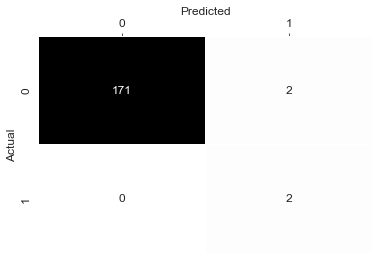



 DBSCAN FOR USER 4414533 

Data
 - Cantidad de observaciones        : 17
 - Cantidad de observaciones fraude : 3

Clusters Info
 - class 0: number of points 13
 - class -1: number of points 4
 - TFP: 7.14% | Accuracy: 94.12% | Recall: 100.0%  | Precision: 75.0% | F1: 85.71%
 - Conf Matrix:


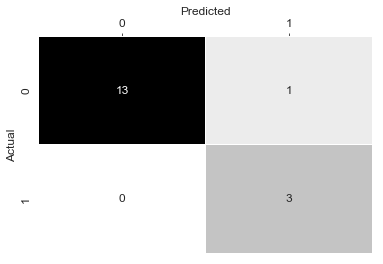



 DBSCAN FOR USER 4490938 

Data
 - Cantidad de observaciones        : 184
 - Cantidad de observaciones fraude : 1

Clusters Info
 - class 0: number of points 183
 - class -1: number of points 1
 - TFP: 0.0% | Accuracy: 100.0% | Recall: 100.0%  | Precision: 100.0% | F1: 100.0%
 - Conf Matrix:


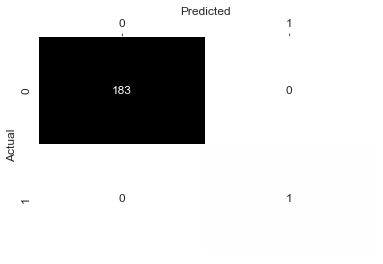



 DBSCAN FOR USER 4502203 

Data
 - Cantidad de observaciones        : 28
 - Cantidad de observaciones fraude : 2

Clusters Info
 - class 0: number of points 24
 - class -1: number of points 4
 - TFP: 7.69% | Accuracy: 92.86% | Recall: 100.0%  | Precision: 50.0% | F1: 66.67%
 - Conf Matrix:


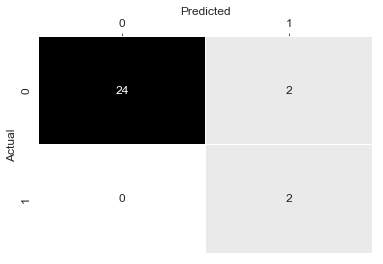



 DBSCAN FOR USER 4547845 

Data
 - Cantidad de observaciones        : 73
 - Cantidad de observaciones fraude : 1

Clusters Info
 - class 0: number of points 66
 - class -1: number of points 7
 - TFP: 8.33% | Accuracy: 91.78% | Recall: 100.0%  | Precision: 14.29% | F1: 25.01%
 - Conf Matrix:


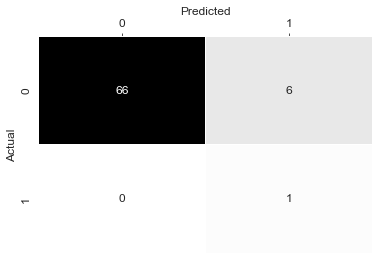



 DBSCAN FOR USER 4554110 

Data
 - Cantidad de observaciones        : 16
 - Cantidad de observaciones fraude : 4

Clusters Info
 - class 0: number of points 12
 - class -1: number of points 4
 - TFP: 0.0% | Accuracy: 100.0% | Recall: 100.0%  | Precision: 100.0% | F1: 100.0%
 - Conf Matrix:


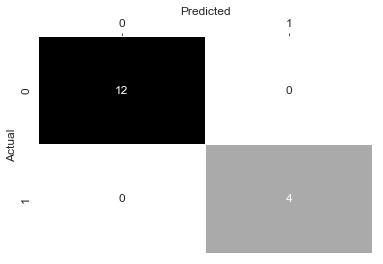



 DBSCAN FOR USER 4699985 

Data
 - Cantidad de observaciones        : 164
 - Cantidad de observaciones fraude : 2

Clusters Info
 - class 0: number of points 162
 - class -1: number of points 2
 - TFP: 0.0% | Accuracy: 100.0% | Recall: 100.0%  | Precision: 100.0% | F1: 100.0%
 - Conf Matrix:


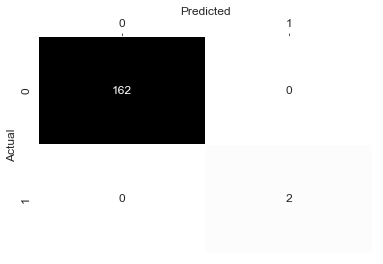



 DBSCAN FOR USER 4876393 

Data
 - Cantidad de observaciones        : 91
 - Cantidad de observaciones fraude : 3

Clusters Info
 - class 0: number of points 88
 - class -1: number of points 3
 - TFP: 0.0% | Accuracy: 100.0% | Recall: 100.0%  | Precision: 100.0% | F1: 100.0%
 - Conf Matrix:


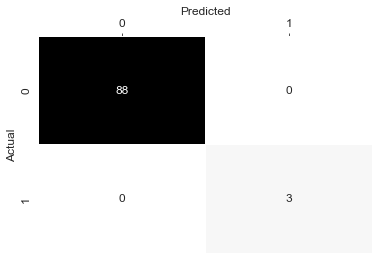



 DBSCAN FOR USER 5038220 

Data
 - Cantidad de observaciones        : 150
 - Cantidad de observaciones fraude : 1

Clusters Info
 - class 0: number of points 148
 - class -1: number of points 2
 - TFP: 0.67% | Accuracy: 99.33% | Recall: 100.0%  | Precision: 50.0% | F1: 66.67%
 - Conf Matrix:


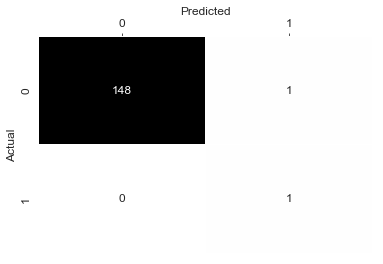



 DBSCAN FOR USER 5090567 

Data
 - Cantidad de observaciones        : 27
 - Cantidad de observaciones fraude : 1

Clusters Info
 - class 0: number of points 27
 - TFP: 0.0% | Accuracy: 96.3% | Recall: 0.0%  | Precision: X% | F1: X%
 - Conf Matrix:


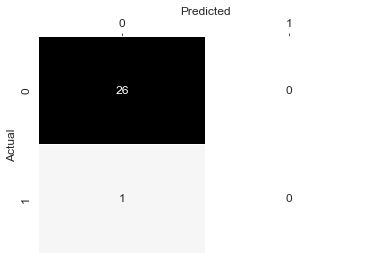



 DBSCAN FOR USER 5189544 

Data
 - Cantidad de observaciones        : 17
 - Cantidad de observaciones fraude : 2

Clusters Info
 - class 0: number of points 13
 - class -1: number of points 4
 - TFP: 13.33% | Accuracy: 88.24% | Recall: 100.0%  | Precision: 50.0% | F1: 66.67%
 - Conf Matrix:


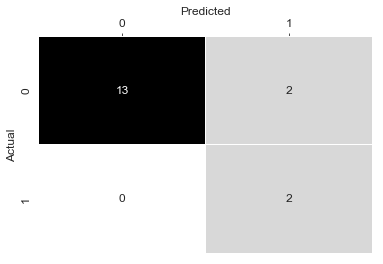



 DBSCAN FOR USER 5416930 

Data
 - Cantidad de observaciones        : 105
 - Cantidad de observaciones fraude : 1

Clusters Info
 - class 0: number of points 105
 - TFP: 0.0% | Accuracy: 99.05% | Recall: 0.0%  | Precision: X% | F1: X%
 - Conf Matrix:


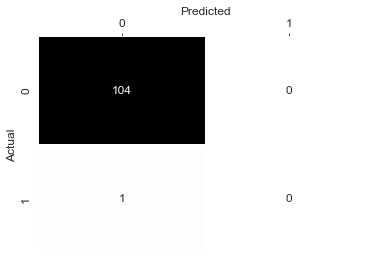



 DBSCAN FOR USER 5434601 

Data
 - Cantidad de observaciones        : 18
 - Cantidad de observaciones fraude : 2

Clusters Info
 - class 0: number of points 14
 - class -1: number of points 4
 - TFP: 12.5% | Accuracy: 88.89% | Recall: 100.0%  | Precision: 50.0% | F1: 66.67%
 - Conf Matrix:


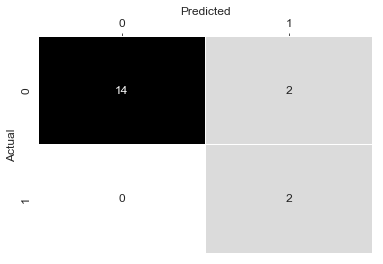



 DBSCAN FOR USER 5660326 

Data
 - Cantidad de observaciones        : 40
 - Cantidad de observaciones fraude : 3

Clusters Info
 - class 0: number of points 37
 - class -1: number of points 3
 - TFP: 0.0% | Accuracy: 100.0% | Recall: 100.0%  | Precision: 100.0% | F1: 100.0%
 - Conf Matrix:


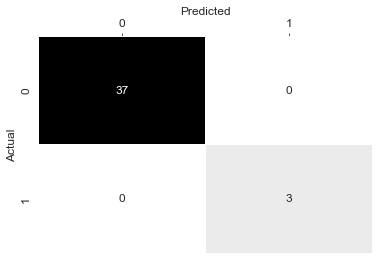



 DBSCAN FOR USER 5714477 

Data
 - Cantidad de observaciones        : 46
 - Cantidad de observaciones fraude : 2

Clusters Info
 - class 0: number of points 46
 - TFP: 0.0% | Accuracy: 95.65% | Recall: 0.0%  | Precision: X% | F1: X%
 - Conf Matrix:


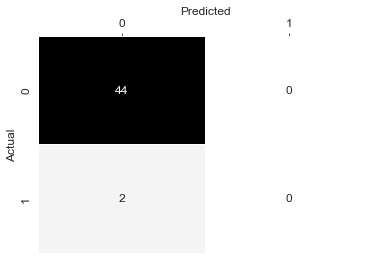



 DBSCAN FOR USER 5785765 

Data
 - Cantidad de observaciones        : 95
 - Cantidad de observaciones fraude : 4

Clusters Info
 - class 0: number of points 91
 - class -1: number of points 4
 - TFP: 0.0% | Accuracy: 100.0% | Recall: 100.0%  | Precision: 100.0% | F1: 100.0%
 - Conf Matrix:


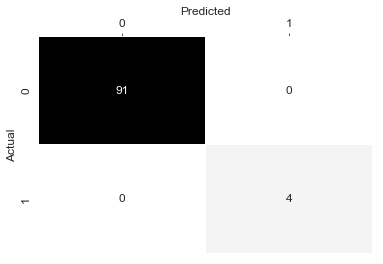



 DBSCAN FOR USER 6060700 

Data
 - Cantidad de observaciones        : 79
 - Cantidad de observaciones fraude : 2

Clusters Info
 - class 0: number of points 79
 - TFP: 0.0% | Accuracy: 97.47% | Recall: 0.0%  | Precision: X% | F1: X%
 - Conf Matrix:


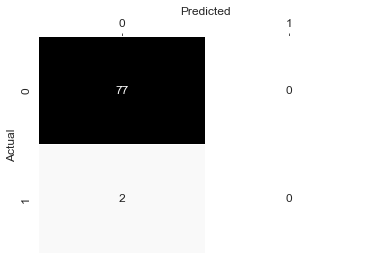



 DBSCAN FOR USER 6181483 

Data
 - Cantidad de observaciones        : 137
 - Cantidad de observaciones fraude : 1

Clusters Info
 - class 0: number of points 21
 - class 1: number of points 116
 - TFP: 0.0% | Accuracy: 99.27% | Recall: 0.0%  | Precision: X% | F1: X%
 - Conf Matrix:


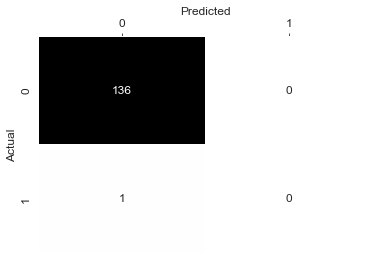



 DBSCAN FOR USER 6395537 

Data
 - Cantidad de observaciones        : 15
 - Cantidad de observaciones fraude : 2

Clusters Info
 - class -1: number of points 15
 - TFP: 100.0% | Accuracy: 13.33% | Recall: 100.0%  | Precision: 13.33% | F1: 23.52%
 - Conf Matrix:


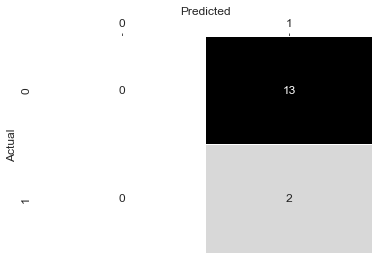



 DBSCAN FOR USER 6433965 

Data
 - Cantidad de observaciones        : 185
 - Cantidad de observaciones fraude : 1

Clusters Info
 - class 0: number of points 185
 - TFP: 0.0% | Accuracy: 99.46% | Recall: 0.0%  | Precision: X% | F1: X%
 - Conf Matrix:


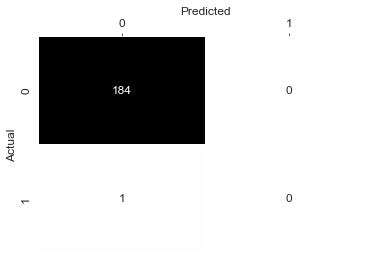



 DBSCAN FOR USER 6488331 

Data
 - Cantidad de observaciones        : 47
 - Cantidad de observaciones fraude : 1

Clusters Info
 - class 0: number of points 43
 - class -1: number of points 4
 - TFP: 6.52% | Accuracy: 93.62% | Recall: 100.0%  | Precision: 25.0% | F1: 40.0%
 - Conf Matrix:


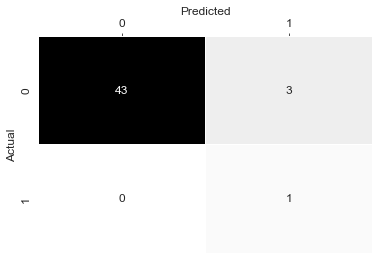



 DBSCAN FOR USER 6619023 

Data
 - Cantidad de observaciones        : 47
 - Cantidad de observaciones fraude : 2

Clusters Info
 - class 0: number of points 45
 - class -1: number of points 2
 - TFP: 0.0% | Accuracy: 100.0% | Recall: 100.0%  | Precision: 100.0% | F1: 100.0%
 - Conf Matrix:


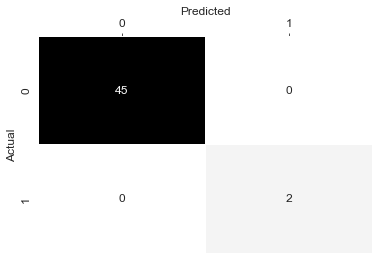



 DBSCAN FOR USER 6726081 

Data
 - Cantidad de observaciones        : 45
 - Cantidad de observaciones fraude : 2

Clusters Info
 - class 0: number of points 36
 - class 1: number of points 9
 - TFP: 0.0% | Accuracy: 95.56% | Recall: 0.0%  | Precision: X% | F1: X%
 - Conf Matrix:


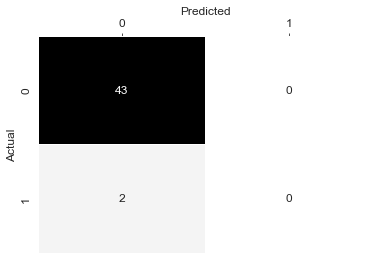



 DBSCAN FOR USER 6760509 

Data
 - Cantidad de observaciones        : 153
 - Cantidad de observaciones fraude : 2

Clusters Info
 - class 0: number of points 150
 - class -1: number of points 3
 - TFP: 1.99% | Accuracy: 96.73% | Recall: 0.0%  | Precision: 0.0% | F1: 0.0%
 - Conf Matrix:


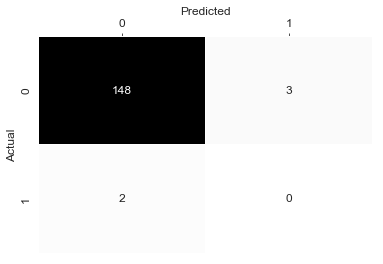



 DBSCAN FOR USER 6915402 

Data
 - Cantidad de observaciones        : 144
 - Cantidad de observaciones fraude : 1

Clusters Info
 - class 0: number of points 142
 - class -1: number of points 2
 - TFP: 0.7% | Accuracy: 99.31% | Recall: 100.0%  | Precision: 50.0% | F1: 66.67%
 - Conf Matrix:


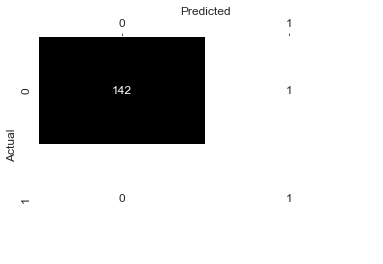



 DBSCAN FOR USER 6992018 

Data
 - Cantidad de observaciones        : 22
 - Cantidad de observaciones fraude : 4

Clusters Info
 - class 0: number of points 22
 - TFP: 0.0% | Accuracy: 81.82% | Recall: 0.0%  | Precision: X% | F1: X%
 - Conf Matrix:


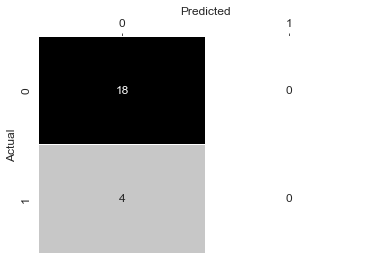



 DBSCAN FOR USER 7244212 

Data
 - Cantidad de observaciones        : 18
 - Cantidad de observaciones fraude : 3

Clusters Info
 - class 0: number of points 9
 - class 1: number of points 9
 - TFP: 0.0% | Accuracy: 83.33% | Recall: 0.0%  | Precision: X% | F1: X%
 - Conf Matrix:


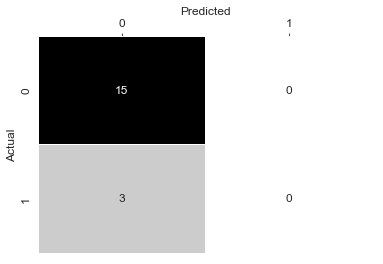



 DBSCAN FOR USER 7522450 

Data
 - Cantidad de observaciones        : 39
 - Cantidad de observaciones fraude : 1

Clusters Info
 - class 0: number of points 38
 - class -1: number of points 1
 - TFP: 0.0% | Accuracy: 100.0% | Recall: 100.0%  | Precision: 100.0% | F1: 100.0%
 - Conf Matrix:


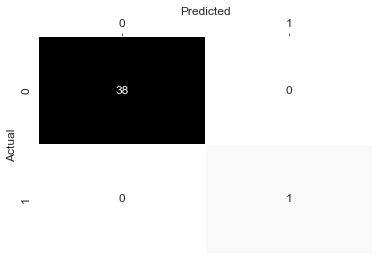



 DBSCAN FOR USER 7570249 

Data
 - Cantidad de observaciones        : 21
 - Cantidad de observaciones fraude : 1

Clusters Info
 - class 0: number of points 18
 - class -1: number of points 3
 - TFP: 10.0% | Accuracy: 90.48% | Recall: 100.0%  | Precision: 33.33% | F1: 50.0%
 - Conf Matrix:


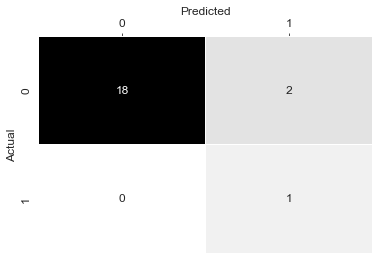



 DBSCAN FOR USER 7575855 

Data
 - Cantidad de observaciones        : 24
 - Cantidad de observaciones fraude : 1

Clusters Info
 - class 0: number of points 24
 - TFP: 0.0% | Accuracy: 95.83% | Recall: 0.0%  | Precision: X% | F1: X%
 - Conf Matrix:


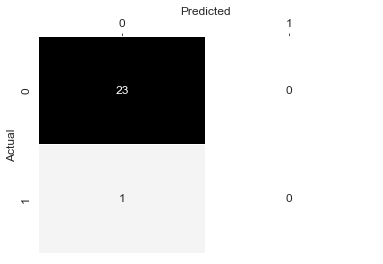



 DBSCAN FOR USER 7669090 

Data
 - Cantidad de observaciones        : 15
 - Cantidad de observaciones fraude : 1

Clusters Info
 - class 0: number of points 13
 - class -1: number of points 2
 - TFP: 7.14% | Accuracy: 93.33% | Recall: 100.0%  | Precision: 50.0% | F1: 66.67%
 - Conf Matrix:


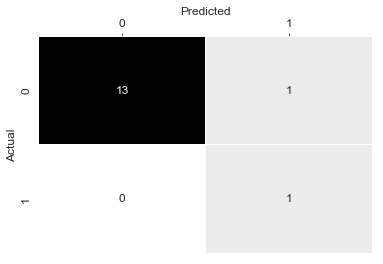



*******************************
 METRICAS GLOBALES DEL MODELO :
*******************************
FP Global: 1.19% | Accuracy: 97.96% | Fraudes atrapados: 60.0% | Recall Avg: 62.3% | Precision Avg: 64.7% | F1 Avg: 72.29



In [42]:
users = list(data['id_usuario'].unique())
F1,Recall_avg,Precision_avg,FP,TP,TN,FN = run_clusters(1.7,9,users,data,vars_list_1,output="Y")

In [43]:
FP

66

In [44]:
TP

75

In [45]:
TN

5494

In [46]:
FN

50

In [47]:
len(users)

61

In [48]:
# Levanto data de los montos por fraude por usuario
montos_fraudes = pd.read_excel("monto_fraude_por_usuario.xlsx")

In [49]:
df_montos = montos_fraudes[montos_fraudes.id_usuario.isin(users)]

In [50]:
# monto en pesos de los fraudes: 
df_montos["Monto Fraude Pesos"].sum()

28810068

In [51]:
len(df_montos)

61

In [52]:
costo_promedio_por_fraude = df_montos["Monto Fraude Pesos"].sum() / (TP + FN)

In [53]:
# este es el costo promedio por fraude. Es decir, lo que se ahorra en cada verdadero positivo (TP)
costo_promedio_por_fraude

230480.544

In [54]:
# Lo que ahorra el modelo
ganancia = TP*costo_promedio_por_fraude; ganancia

17286040.8

4.2. Estimacion de pérdida por el modelo seleccionado

    Los falsos positivos generan un efecto "pérdida" del modelo. Por este motivo se decide relativizar la ganancia teniendo en cuenta los eventos negativos, mal catalogados como positivos (clientes genuinos identificados como fraudulentos)

    Para esto, al total de ganancia del modelo, se le resta el porcentaje de falsos positivos. 
    El FP global del modelo fue de 1,19%.

In [55]:
perdida = ganancia*(0.0119)

4.3. Estimacion del impacto neto: 

    impacto = ganancia - perdida

In [56]:
impacto = ganancia - perdida; impacto

17080336.91448

#### 5. Corro el modelo para los usuarios que no presentaron fraudes:

In [60]:
# genero el DataFrame "data_nf", que son los usuarios que NO presentan casos de fraude

data_nf = pd.read_excel(open('raw_data_no_estafas.xlsx', 'rb'),
                     converters = {
                         'hora_evento':str, 'user_tuvo_estafa':str, 'Label':str, 'id_evento':str, 'id_usuario':str, 'id_sesion':str,
                         'fecha':str, 'hash_usuario':str, 'tipo_evento':str, 'score':str, 'regla_1_riesgo':str,
                         'score_1_riesgo':str, 'regla_2_riesgo':str, 'score_2_riesgo':str, 'regla_3_riesgo':str,
                         'score_3_riesgo':str, 'regla_4_riesgo':str, 'score_4_riesgo':str, 'decision':str, 'cookie':str,
                         'agente_busqueda_hash':str, 'huella_software_hash':str, 'plugin_navegador_hash':str,
                         'pantalla_hash':str, 'lenguaje_sistema_operativo':str, 'lenguaje_usuario':str, 'lenguaje_navegador_detalles':str,
                         'lenguaje_navegador':str, 'zona_horaria':str, 'ip_address':str, 'ip_pais':str, 'ip_region':str,
                         'ip_ciudad':str, 'ip_isp':str, 'canal':str, 'cookie_persistent':str, 'data_1':str,
                         'data_2':str, 'data_4':str, 'data_5':str, 'data_7':str, 'data_8':str, 'data_9':str, 
                         'data_13':str, 'data_29':str, 'data_30':str, 'data_31':str, 'data_37':str, 'data_40':str,
                         'data_41':str, 'data_42':str, 'data_43':str, 'data_44':str, 'data_45':str, 'data_56':str,
                         'data_60':str, 'data_77':str, 'data_78':str, 'data_80':str, 'data_82':str, 'data_83':str,
                         'data_3':str, 'antiguedad_cookies':str, 'data_100':str, 'data_107':str, 'antiguedad_device':str, 'data_115':str, 
                         'velocity_isp_web_10d':str, 'velocity_isp_web_30d':str, 'velocity_isp_mobile_10d':str,
                         'velocity_isp_mobile_30d':str, 'antiguedad_geodata':str, 'sistema_operativo':str, 'navegador_nombre':str,
                         'navegador_version':str, 'rdp_trojan_collection_status':str, 'ip_isp_nombre':str
                     }
                    )

# relleno los null con un valor, para que no de error, ademas me interesa que los null compartan eje
data_nf.fillna('9999', inplace = True) 


# genero la variable 'navegador_caract' que concatena  'navegador_nombre' con 'navegador_version'
data_nf['navegador_caract'] = data_nf['navegador_nombre'] + data_nf['navegador_version']

# tambien genero una nueva variable user_caract a partir de las 4 variables HASH: 
data_nf['user_caract'] = data_nf['agente_busqueda_hash'] + '_'+ data_nf['huella_software_hash'] + '_' + data_nf['plugin_navegador_hash'] + '_'+ data_nf['pantalla_hash']



In [61]:
# tomo una muestra de 100
users_nf = r.sample(list(data_nf['id_usuario'].unique()),100)



 DBSCAN FOR USER 7167828 

Data
 - Cantidad de observaciones        : 54
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 54
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


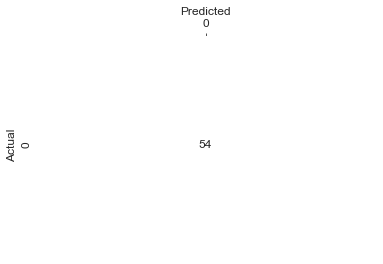



 DBSCAN FOR USER 7735265 

Data
 - Cantidad de observaciones        : 299
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 299
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


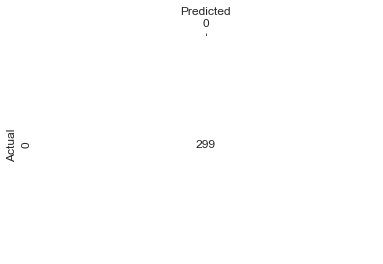



 DBSCAN FOR USER 6251744 

Data
 - Cantidad de observaciones        : 98
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 98
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


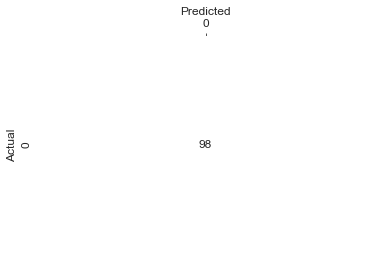



 DBSCAN FOR USER 6206828 

Data
 - Cantidad de observaciones        : 92
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 92
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


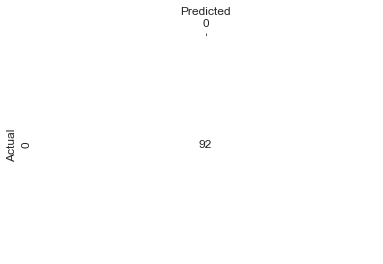



 DBSCAN FOR USER 6576492 

Data
 - Cantidad de observaciones        : 166
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 166
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


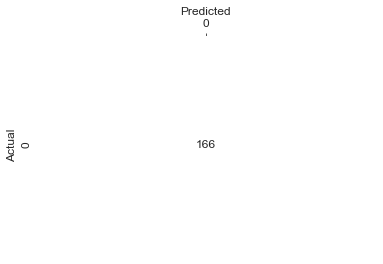



 DBSCAN FOR USER 3450822 

Data
 - Cantidad de observaciones        : 73
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 73
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


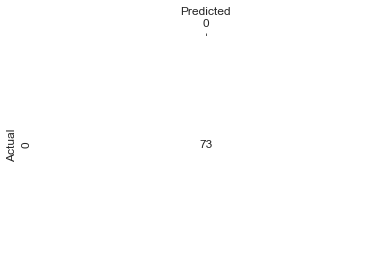



 DBSCAN FOR USER 4398261 

Data
 - Cantidad de observaciones        : 51
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 51
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


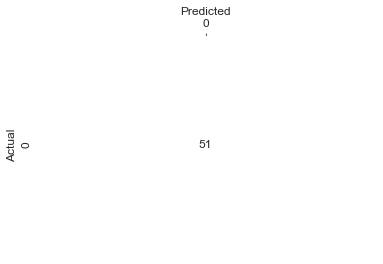



 DBSCAN FOR USER 5573106 

Data
 - Cantidad de observaciones        : 89
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 89
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


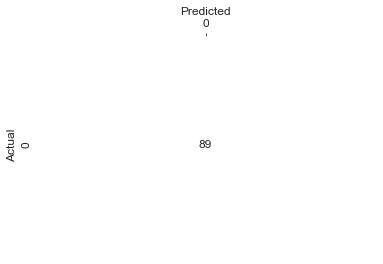



 DBSCAN FOR USER 5846286 

Data
 - Cantidad de observaciones        : 285
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 284
 - class -1: number of points 1
 - TFP: 0.35% | Accuracy: 99.65% | Recall: X%  | Precision: 0.0% | F1: X%
 - Conf Matrix:


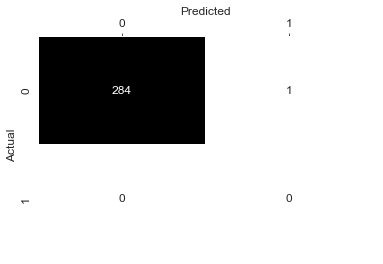



 DBSCAN FOR USER 55910 

Data
 - Cantidad de observaciones        : 153
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 153
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


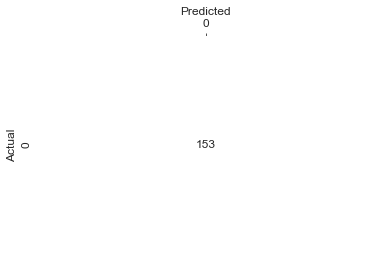



 DBSCAN FOR USER 4662625 

Data
 - Cantidad de observaciones        : 112
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 112
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


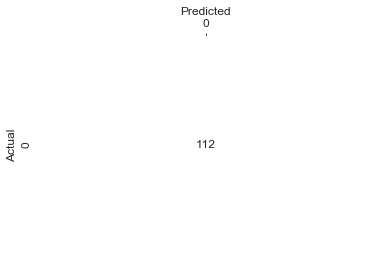



 DBSCAN FOR USER 1315721 

Data
 - Cantidad de observaciones        : 304
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 297
 - class -1: number of points 7
 - TFP: 2.3% | Accuracy: 97.7% | Recall: X%  | Precision: 0.0% | F1: X%
 - Conf Matrix:


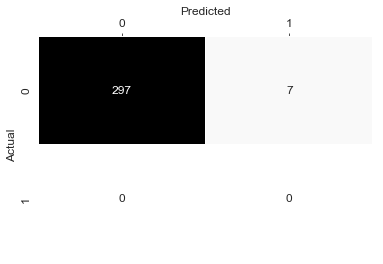



 DBSCAN FOR USER 4980002 

Data
 - Cantidad de observaciones        : 259
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 259
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


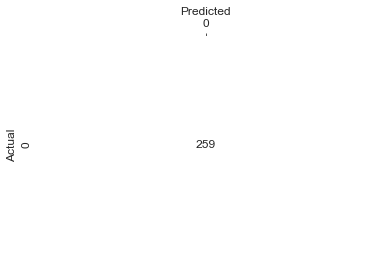



 DBSCAN FOR USER 2014337 

Data
 - Cantidad de observaciones        : 435
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 435
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


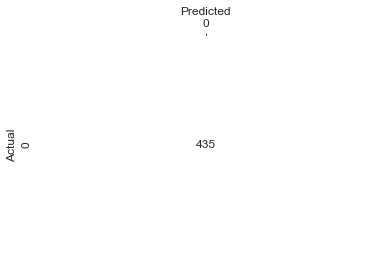



 DBSCAN FOR USER 2554480 

Data
 - Cantidad de observaciones        : 60
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 60
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


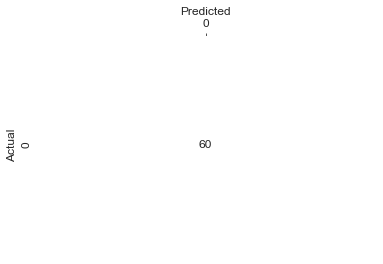



 DBSCAN FOR USER 2098600 

Data
 - Cantidad de observaciones        : 459
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 458
 - class -1: number of points 1
 - TFP: 0.22% | Accuracy: 99.78% | Recall: X%  | Precision: 0.0% | F1: X%
 - Conf Matrix:


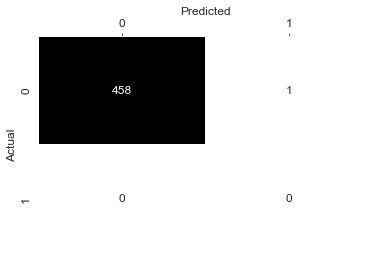



 DBSCAN FOR USER 648034 

Data
 - Cantidad de observaciones        : 376
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 376
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


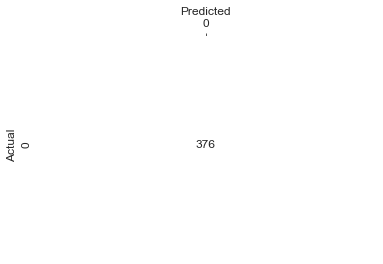



 DBSCAN FOR USER 7014783 

Data
 - Cantidad de observaciones        : 89
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 89
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


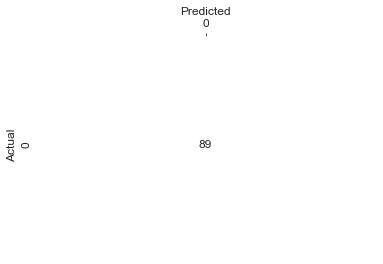



 DBSCAN FOR USER 130275 

Data
 - Cantidad de observaciones        : 96
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 96
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


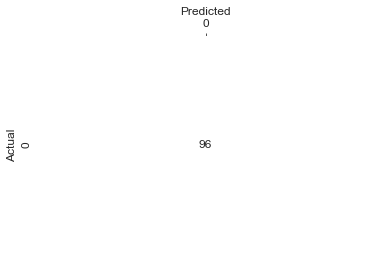



 DBSCAN FOR USER 4121682 

Data
 - Cantidad de observaciones        : 489
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 482
 - class -1: number of points 7
 - TFP: 1.43% | Accuracy: 98.57% | Recall: X%  | Precision: 0.0% | F1: X%
 - Conf Matrix:


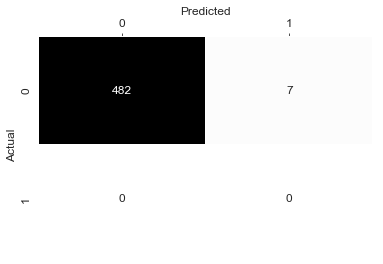



 DBSCAN FOR USER 3723254 

Data
 - Cantidad de observaciones        : 54
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 54
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


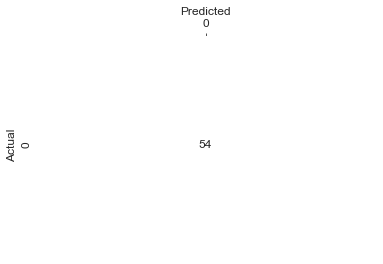



 DBSCAN FOR USER 4312945 

Data
 - Cantidad de observaciones        : 235
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 235
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


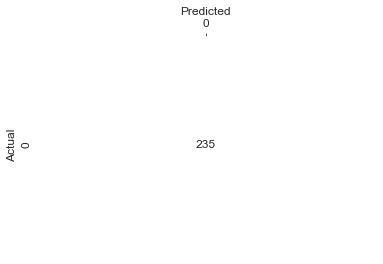



 DBSCAN FOR USER 3012742 

Data
 - Cantidad de observaciones        : 296
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 296
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


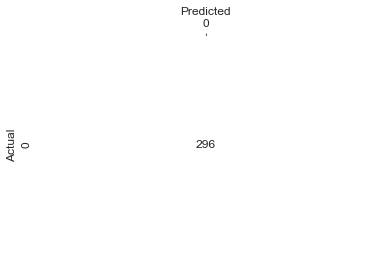



 DBSCAN FOR USER 7496734 

Data
 - Cantidad de observaciones        : 177
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 175
 - class -1: number of points 2
 - TFP: 1.13% | Accuracy: 98.87% | Recall: X%  | Precision: 0.0% | F1: X%
 - Conf Matrix:


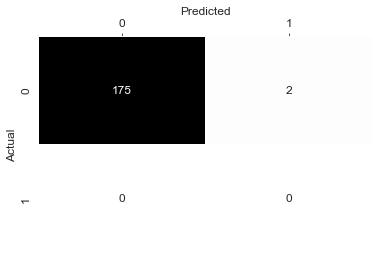



 DBSCAN FOR USER 7006201 

Data
 - Cantidad de observaciones        : 78
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 78
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


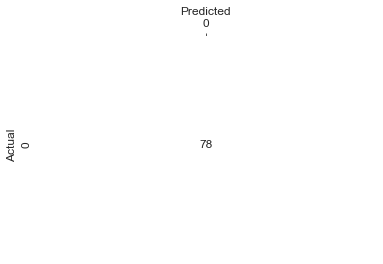



 DBSCAN FOR USER 2395086 

Data
 - Cantidad de observaciones        : 583
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 583
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


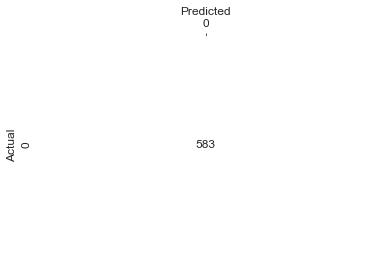



 DBSCAN FOR USER 1607929 

Data
 - Cantidad de observaciones        : 225
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 200
 - class 1: number of points 21
 - class -1: number of points 4
 - TFP: 1.78% | Accuracy: 98.22% | Recall: X%  | Precision: 0.0% | F1: X%
 - Conf Matrix:


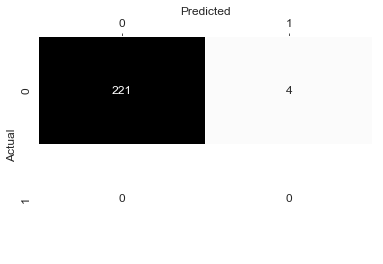



 DBSCAN FOR USER 6760681 

Data
 - Cantidad de observaciones        : 68
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 68
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


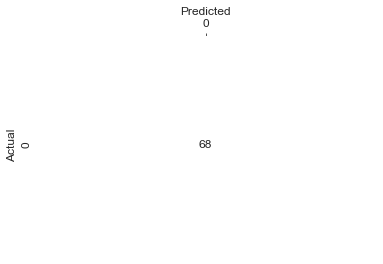



 DBSCAN FOR USER 4071973 

Data
 - Cantidad de observaciones        : 50
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 50
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


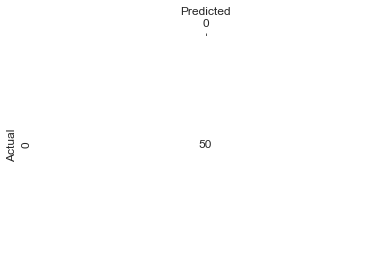



 DBSCAN FOR USER 4774625 

Data
 - Cantidad de observaciones        : 104
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 102
 - class -1: number of points 2
 - TFP: 1.92% | Accuracy: 98.08% | Recall: X%  | Precision: 0.0% | F1: X%
 - Conf Matrix:


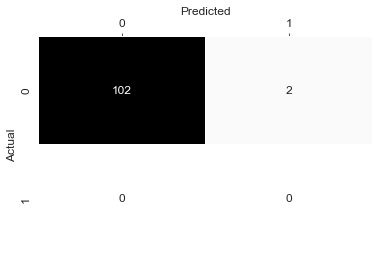



 DBSCAN FOR USER 2590665 

Data
 - Cantidad de observaciones        : 246
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 245
 - class -1: number of points 1
 - TFP: 0.41% | Accuracy: 99.59% | Recall: X%  | Precision: 0.0% | F1: X%
 - Conf Matrix:


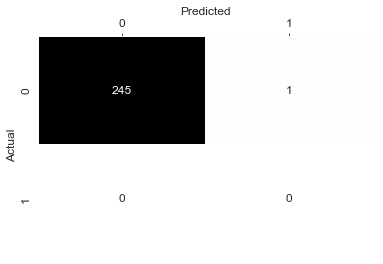



 DBSCAN FOR USER 2296837 

Data
 - Cantidad de observaciones        : 95
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 95
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


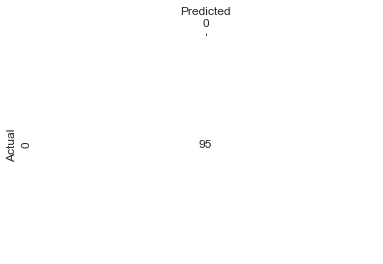



 DBSCAN FOR USER 7180974 

Data
 - Cantidad de observaciones        : 215
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 215
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


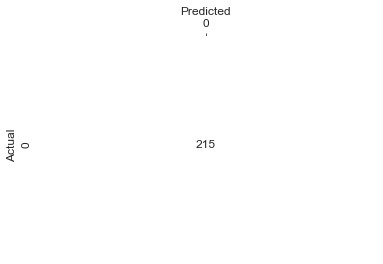



 DBSCAN FOR USER 4386427 

Data
 - Cantidad de observaciones        : 116
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 116
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


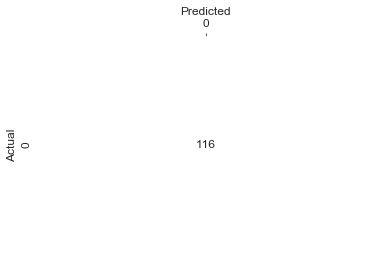



 DBSCAN FOR USER 4869588 

Data
 - Cantidad de observaciones        : 60
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 30
 - class 1: number of points 30
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


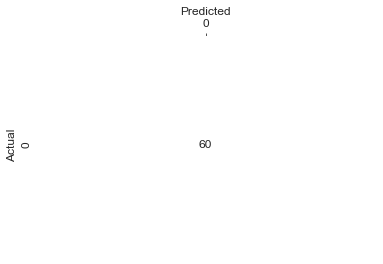



 DBSCAN FOR USER 6572607 

Data
 - Cantidad de observaciones        : 84
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 84
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


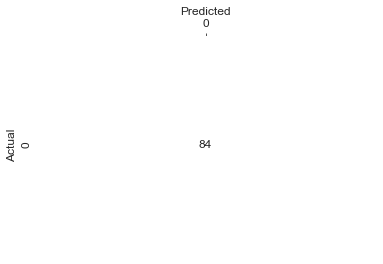



 DBSCAN FOR USER 1493671 

Data
 - Cantidad de observaciones        : 386
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 386
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


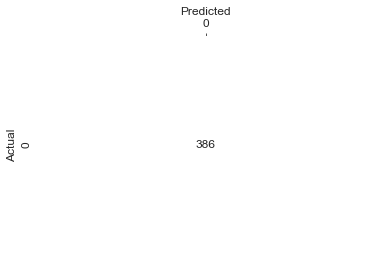



 DBSCAN FOR USER 2650500 

Data
 - Cantidad de observaciones        : 51
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 39
 - class 1: number of points 12
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


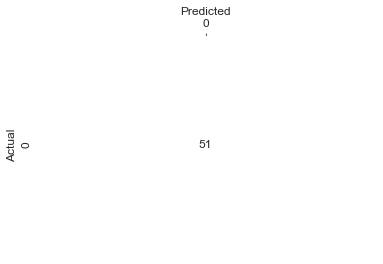



 DBSCAN FOR USER 2209372 

Data
 - Cantidad de observaciones        : 231
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 231
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


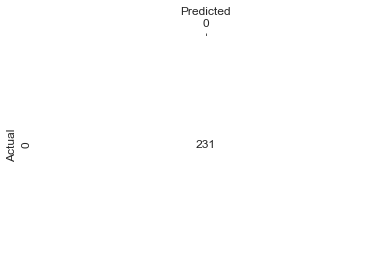



 DBSCAN FOR USER 3974072 

Data
 - Cantidad de observaciones        : 112
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 112
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


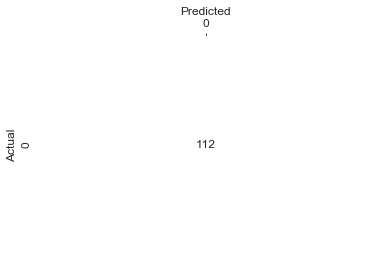



 DBSCAN FOR USER 2834223 

Data
 - Cantidad de observaciones        : 95
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 90
 - class -1: number of points 5
 - TFP: 5.26% | Accuracy: 94.74% | Recall: X%  | Precision: 0.0% | F1: X%
 - Conf Matrix:


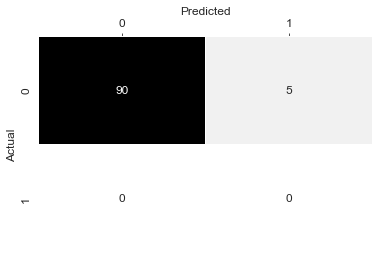



 DBSCAN FOR USER 3436006 

Data
 - Cantidad de observaciones        : 73
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 73
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


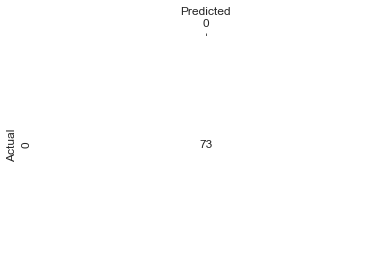



 DBSCAN FOR USER 6716524 

Data
 - Cantidad de observaciones        : 180
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 178
 - class -1: number of points 2
 - TFP: 1.11% | Accuracy: 98.89% | Recall: X%  | Precision: 0.0% | F1: X%
 - Conf Matrix:


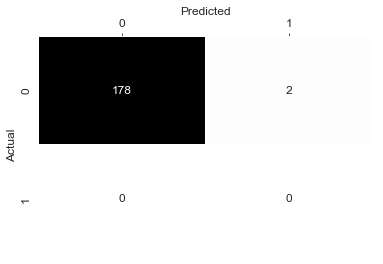



 DBSCAN FOR USER 4474107 

Data
 - Cantidad de observaciones        : 209
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 209
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


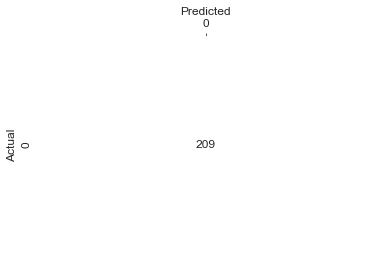



 DBSCAN FOR USER 6916902 

Data
 - Cantidad de observaciones        : 101
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 101
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


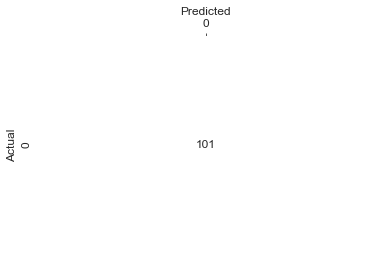



 DBSCAN FOR USER 4273573 

Data
 - Cantidad de observaciones        : 193
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 192
 - class -1: number of points 1
 - TFP: 0.52% | Accuracy: 99.48% | Recall: X%  | Precision: 0.0% | F1: X%
 - Conf Matrix:


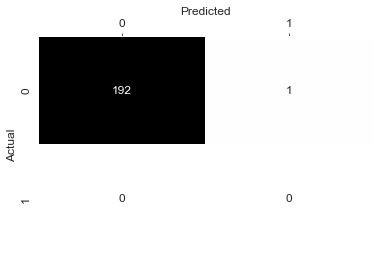



 DBSCAN FOR USER 7150029 

Data
 - Cantidad de observaciones        : 171
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 171
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


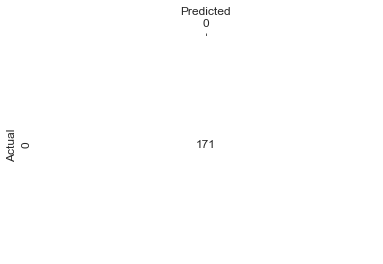



 DBSCAN FOR USER 2963617 

Data
 - Cantidad de observaciones        : 51
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 48
 - class -1: number of points 3
 - TFP: 5.88% | Accuracy: 94.12% | Recall: X%  | Precision: 0.0% | F1: X%
 - Conf Matrix:


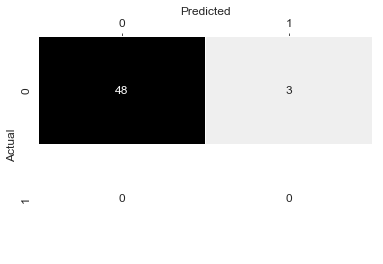



 DBSCAN FOR USER 4118968 

Data
 - Cantidad de observaciones        : 99
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 99
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


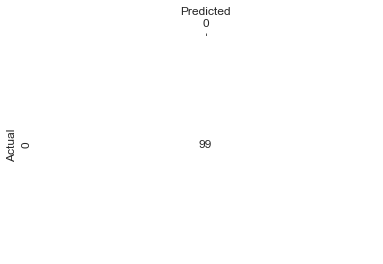



 DBSCAN FOR USER 4111402 

Data
 - Cantidad de observaciones        : 199
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 198
 - class -1: number of points 1
 - TFP: 0.5% | Accuracy: 99.5% | Recall: X%  | Precision: 0.0% | F1: X%
 - Conf Matrix:


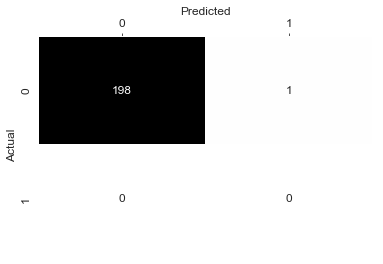



 DBSCAN FOR USER 6265229 

Data
 - Cantidad de observaciones        : 125
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 125
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


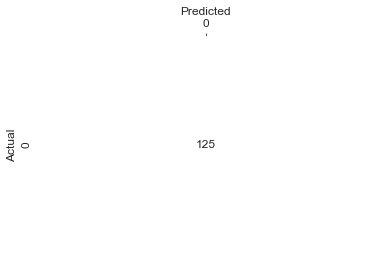



 DBSCAN FOR USER 4193101 

Data
 - Cantidad de observaciones        : 71
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 14
 - class 1: number of points 57
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


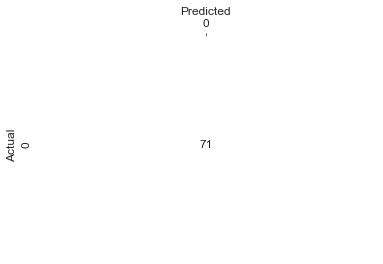



 DBSCAN FOR USER 2355942 

Data
 - Cantidad de observaciones        : 184
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 184
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


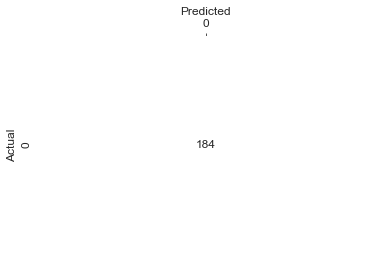



 DBSCAN FOR USER 2557595 

Data
 - Cantidad de observaciones        : 303
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 303
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


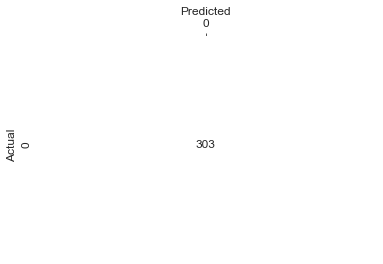



 DBSCAN FOR USER 6783489 

Data
 - Cantidad de observaciones        : 51
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 15
 - class 1: number of points 36
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


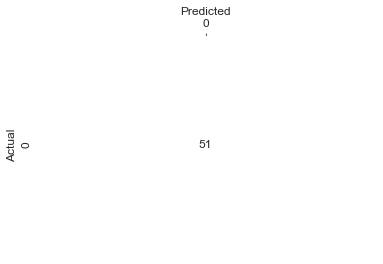



 DBSCAN FOR USER 5835963 

Data
 - Cantidad de observaciones        : 149
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 148
 - class -1: number of points 1
 - TFP: 0.67% | Accuracy: 99.33% | Recall: X%  | Precision: 0.0% | F1: X%
 - Conf Matrix:


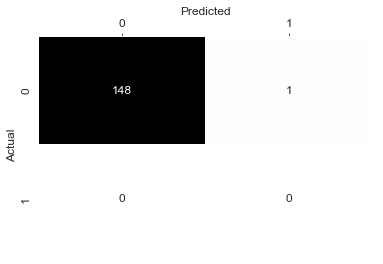



 DBSCAN FOR USER 3168555 

Data
 - Cantidad de observaciones        : 113
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 112
 - class -1: number of points 1
 - TFP: 0.88% | Accuracy: 99.12% | Recall: X%  | Precision: 0.0% | F1: X%
 - Conf Matrix:


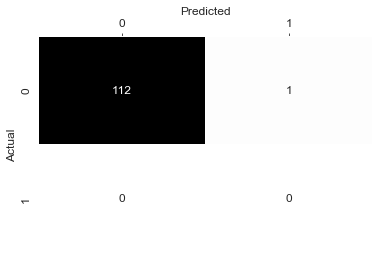



 DBSCAN FOR USER 4316774 

Data
 - Cantidad de observaciones        : 159
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 159
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


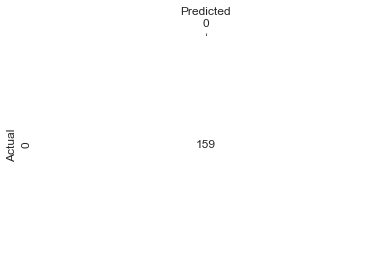



 DBSCAN FOR USER 2248457 

Data
 - Cantidad de observaciones        : 157
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 153
 - class -1: number of points 4
 - TFP: 2.55% | Accuracy: 97.45% | Recall: X%  | Precision: 0.0% | F1: X%
 - Conf Matrix:


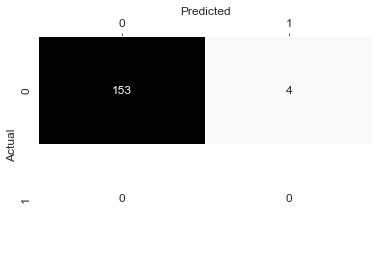



 DBSCAN FOR USER 3193344 

Data
 - Cantidad de observaciones        : 148
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 148
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


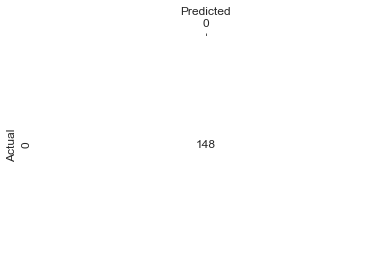



 DBSCAN FOR USER 3622747 

Data
 - Cantidad de observaciones        : 103
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 103
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


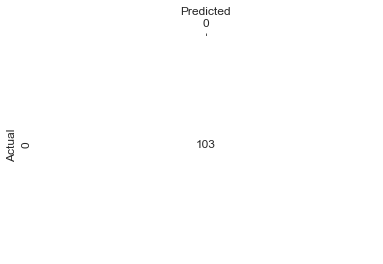



 DBSCAN FOR USER 6165139 

Data
 - Cantidad de observaciones        : 143
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 143
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


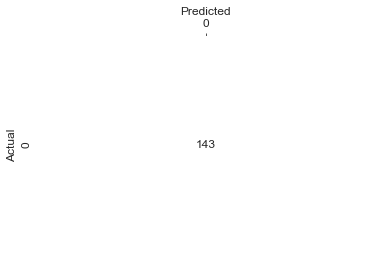



 DBSCAN FOR USER 7026272 

Data
 - Cantidad de observaciones        : 50
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 50
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


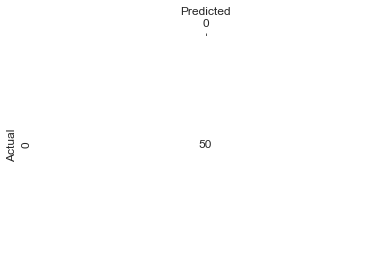



 DBSCAN FOR USER 2523837 

Data
 - Cantidad de observaciones        : 183
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 183
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


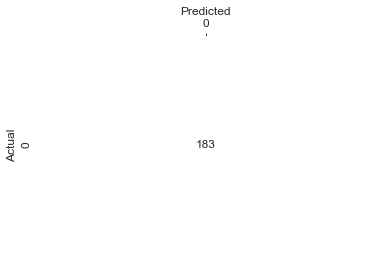



 DBSCAN FOR USER 2703407 

Data
 - Cantidad de observaciones        : 87
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 76
 - class -1: number of points 11
 - TFP: 12.64% | Accuracy: 87.36% | Recall: X%  | Precision: 0.0% | F1: X%
 - Conf Matrix:


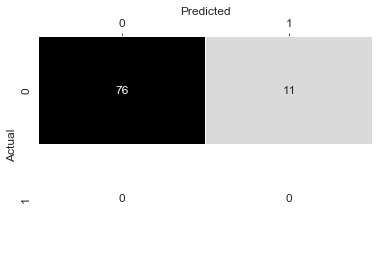



 DBSCAN FOR USER 4330084 

Data
 - Cantidad de observaciones        : 70
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 70
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


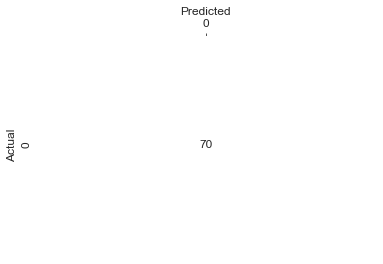



 DBSCAN FOR USER 7343802 

Data
 - Cantidad de observaciones        : 105
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 104
 - class -1: number of points 1
 - TFP: 0.95% | Accuracy: 99.05% | Recall: X%  | Precision: 0.0% | F1: X%
 - Conf Matrix:


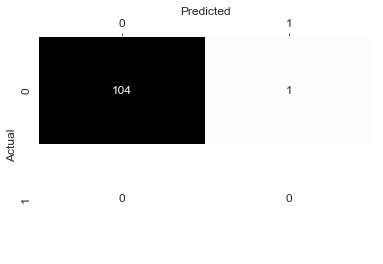



 DBSCAN FOR USER 4826300 

Data
 - Cantidad de observaciones        : 259
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 259
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


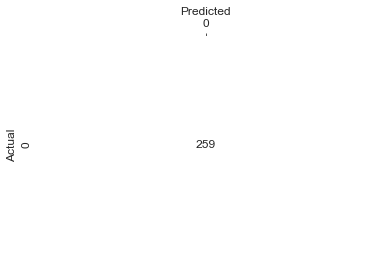



 DBSCAN FOR USER 6809721 

Data
 - Cantidad de observaciones        : 173
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 173
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


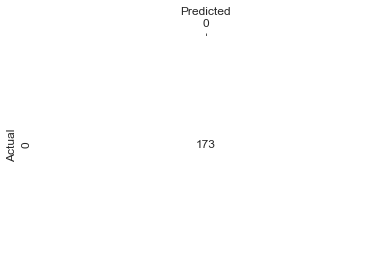



 DBSCAN FOR USER 2279241 

Data
 - Cantidad de observaciones        : 174
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 174
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


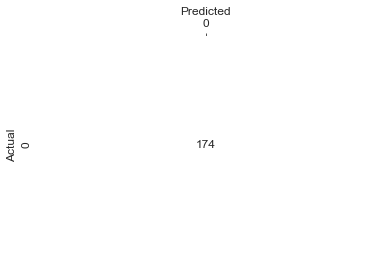



 DBSCAN FOR USER 2353618 

Data
 - Cantidad de observaciones        : 184
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 184
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


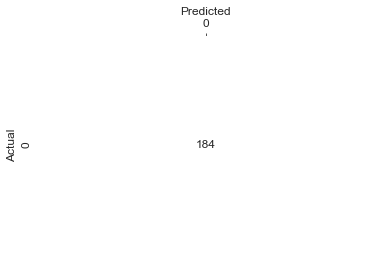



 DBSCAN FOR USER 5165002 

Data
 - Cantidad de observaciones        : 72
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 66
 - class -1: number of points 6
 - TFP: 8.33% | Accuracy: 91.67% | Recall: X%  | Precision: 0.0% | F1: X%
 - Conf Matrix:


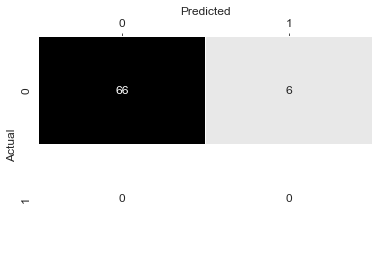



 DBSCAN FOR USER 2907019 

Data
 - Cantidad de observaciones        : 117
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 117
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


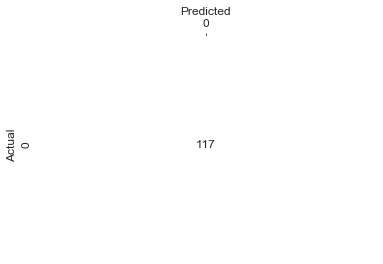



 DBSCAN FOR USER 6517143 

Data
 - Cantidad de observaciones        : 133
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 132
 - class -1: number of points 1
 - TFP: 0.75% | Accuracy: 99.25% | Recall: X%  | Precision: 0.0% | F1: X%
 - Conf Matrix:


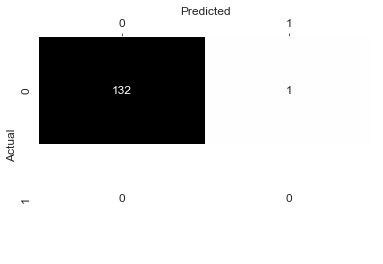



 DBSCAN FOR USER 496762 

Data
 - Cantidad de observaciones        : 651
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 650
 - class -1: number of points 1
 - TFP: 0.15% | Accuracy: 99.85% | Recall: X%  | Precision: 0.0% | F1: X%
 - Conf Matrix:


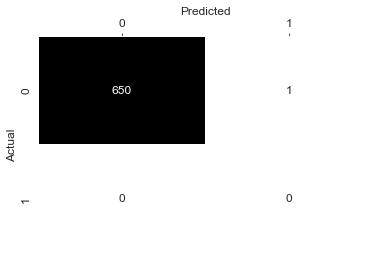



 DBSCAN FOR USER 381554 

Data
 - Cantidad de observaciones        : 64
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 64
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


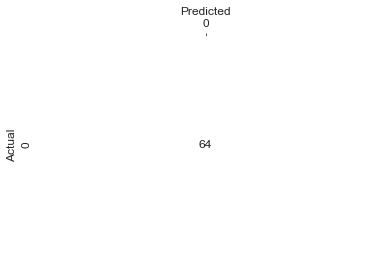



 DBSCAN FOR USER 3995350 

Data
 - Cantidad de observaciones        : 263
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 263
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


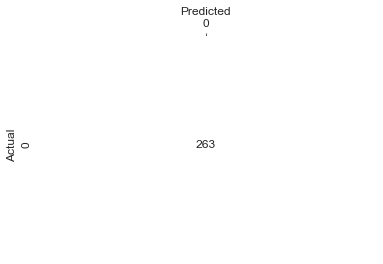



 DBSCAN FOR USER 2289264 

Data
 - Cantidad de observaciones        : 103
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 103
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


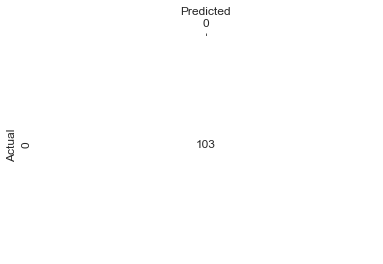



 DBSCAN FOR USER 7370697 

Data
 - Cantidad de observaciones        : 50
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 50
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


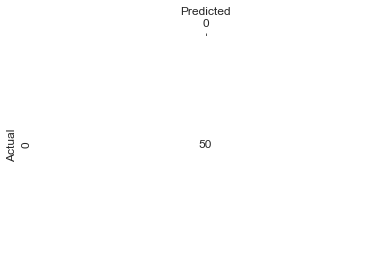



 DBSCAN FOR USER 3357722 

Data
 - Cantidad de observaciones        : 223
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 223
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


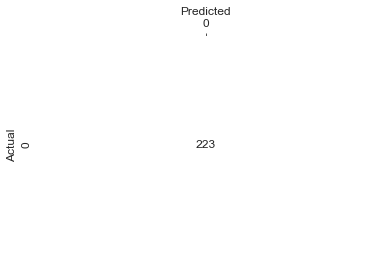



 DBSCAN FOR USER 6505946 

Data
 - Cantidad de observaciones        : 93
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 87
 - class -1: number of points 6
 - TFP: 6.45% | Accuracy: 93.55% | Recall: X%  | Precision: 0.0% | F1: X%
 - Conf Matrix:


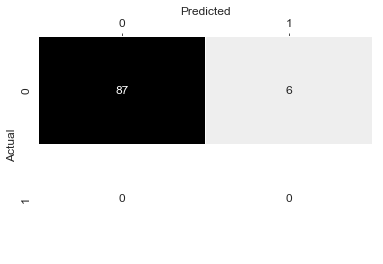



 DBSCAN FOR USER 6979667 

Data
 - Cantidad de observaciones        : 88
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 88
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


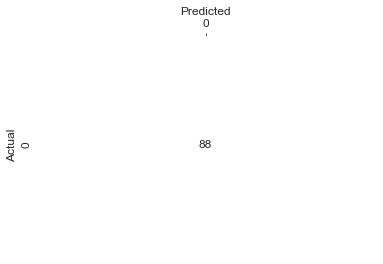



 DBSCAN FOR USER 5737298 

Data
 - Cantidad de observaciones        : 82
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 82
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


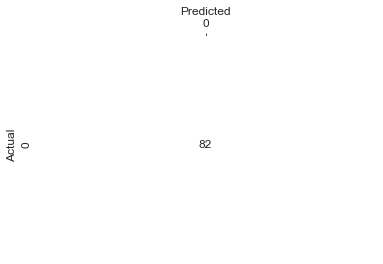



 DBSCAN FOR USER 1593317 

Data
 - Cantidad de observaciones        : 224
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 224
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


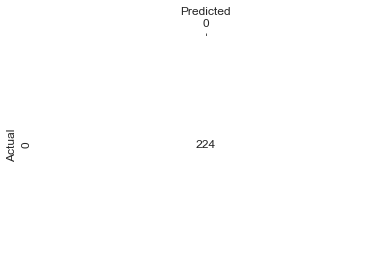



 DBSCAN FOR USER 4284179 

Data
 - Cantidad de observaciones        : 217
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 216
 - class -1: number of points 1
 - TFP: 0.46% | Accuracy: 99.54% | Recall: X%  | Precision: 0.0% | F1: X%
 - Conf Matrix:


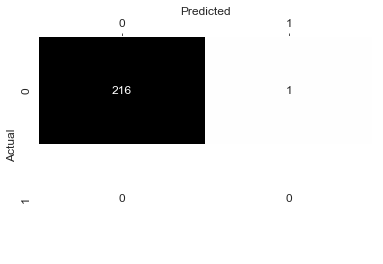



 DBSCAN FOR USER 7553391 

Data
 - Cantidad de observaciones        : 81
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 60
 - class 1: number of points 21
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


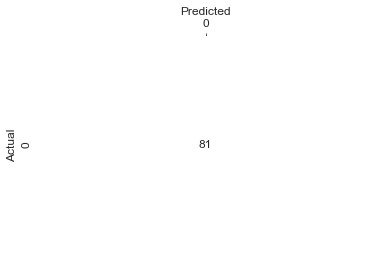



 DBSCAN FOR USER 7296533 

Data
 - Cantidad de observaciones        : 55
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 55
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


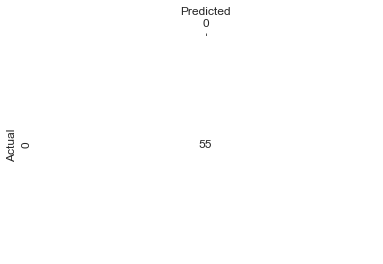



 DBSCAN FOR USER 5290432 

Data
 - Cantidad de observaciones        : 218
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 218
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


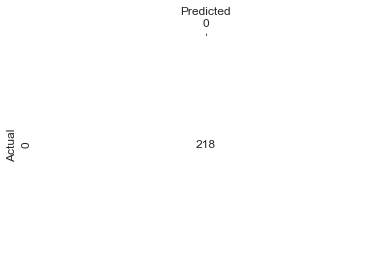



 DBSCAN FOR USER 6998163 

Data
 - Cantidad de observaciones        : 76
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 76
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


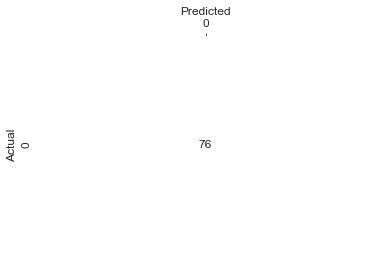



 DBSCAN FOR USER 4317706 

Data
 - Cantidad de observaciones        : 79
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 79
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


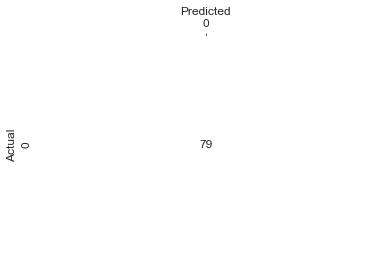



 DBSCAN FOR USER 1573344 

Data
 - Cantidad de observaciones        : 436
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 434
 - class -1: number of points 2
 - TFP: 0.46% | Accuracy: 99.54% | Recall: X%  | Precision: 0.0% | F1: X%
 - Conf Matrix:


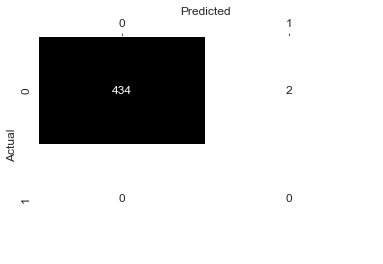



 DBSCAN FOR USER 1520904 

Data
 - Cantidad de observaciones        : 576
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 576
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


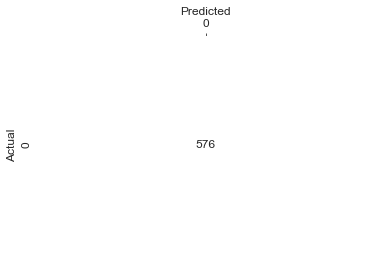



 DBSCAN FOR USER 4463077 

Data
 - Cantidad de observaciones        : 150
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 150
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


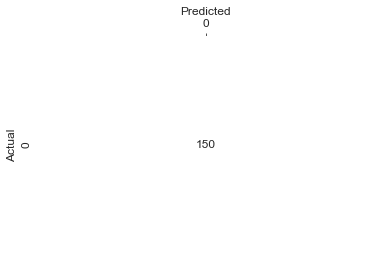



 DBSCAN FOR USER 7267412 

Data
 - Cantidad de observaciones        : 131
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 131
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


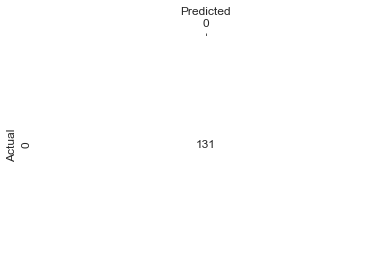



 DBSCAN FOR USER 4317200 

Data
 - Cantidad de observaciones        : 151
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 150
 - class -1: number of points 1
 - TFP: 0.66% | Accuracy: 99.34% | Recall: X%  | Precision: 0.0% | F1: X%
 - Conf Matrix:


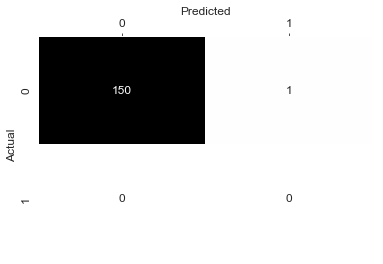



 DBSCAN FOR USER 1100961 

Data
 - Cantidad de observaciones        : 84
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 80
 - class -1: number of points 4
 - TFP: 4.76% | Accuracy: 95.24% | Recall: X%  | Precision: 0.0% | F1: X%
 - Conf Matrix:


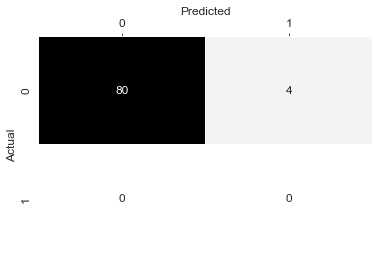



 DBSCAN FOR USER 1520474 

Data
 - Cantidad de observaciones        : 167
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 167
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


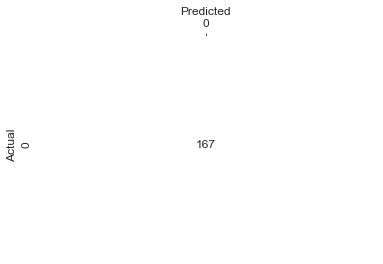



 DBSCAN FOR USER 2245169 

Data
 - Cantidad de observaciones        : 131
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 131
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


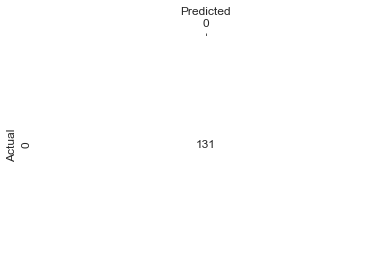



 DBSCAN FOR USER 5533129 

Data
 - Cantidad de observaciones        : 67
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 66
 - class -1: number of points 1
 - TFP: 1.49% | Accuracy: 98.51% | Recall: X%  | Precision: 0.0% | F1: X%
 - Conf Matrix:


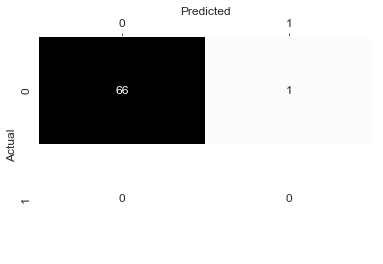



 DBSCAN FOR USER 5159128 

Data
 - Cantidad de observaciones        : 131
 - Cantidad de observaciones fraude : 0

Clusters Info
 - class 0: number of points 131
 - TFP: 0.0% | Accuracy: 100.0% | Recall: X%  | Precision: X% | F1: X%
 - Conf Matrix:


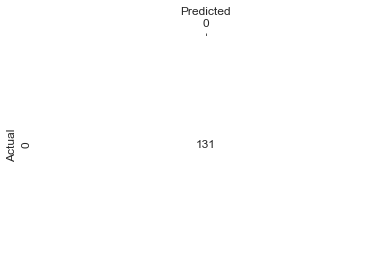



*******************************
 METRICAS GLOBALES DEL MODELO :
*******************************
FP Global: 0.46% | Accuracy: 99.54% | Fraudes atrapados: X% | Recall Avg: nan% | Precision Avg: 0.0% | F1 Avg: nan



In [62]:
F1,Recall_avg,Precision_avg,FP,TP,TN,FN = run_clusters(1.7,9,users_nf,data_nf,vars_list_1,output="Y")

In [63]:
FP

78

In [64]:
TP

0

In [65]:
TN

16702

In [66]:
FN

0

Fin de la notebook